# Literature data reprocessing and calculations
This notebook reprocesses the calculations from the Rapid Response to match exactly calculation methods from PrePost Caldera project ( SO2 mol%, T, XH2O and MC simulations).
The original data contains Raman and SEM-EDS, no EBSD.
The steps are as follows:
- 1. Import dependencies and install packages
- 2. Import dataset and clear up columns not needed
- 3. calculate SO2 mol% from Raman ratios
- 4. Calculate T from olivine only thermometer using SEM-EDS on host olivines
- 5. Calculate XH2O iteratively 
- 6. Calculate final P and D and uncertainty via Monte Carlo simulations
- 7. Exports final dataset to excel for plotting in a separate notebook

## 1. Import packages and setup folders and paths

### Install packages if not installed

In [1]:
#%pip install --upgrade DiadFit
#%pip install DiadFit==1.0.5 some of this will only work in diadfit 1.0.5
#%pip install Thermobar

### Import packages

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import DiadFit as pf
import os
import pickle
pf.__version__


'1.0.5'

### Setup folders and data paths

In [3]:
# This is to make sure the code runs regardless of operating system
if os.name=='posix':
    slash='/'
else:
    slash='\\'

# Set master folder
MasterFolder=os.path.dirname(os.path.dirname(os.getcwd()))

# #Folder to save figures

figpath=MasterFolder +slash+"Data_processing_notebooks"+slash+"Data_reprocessing_Literature"+slash+'Processing Figs'
if not os.path.exists(figpath):
    os.mkdir(figpath)

# Create folder to save full datasets

compilation_folder=MasterFolder +slash+"Data_processing_notebooks"+slash+"Data_reprocessing_Literature"+slash+'Notebook_Compiled_data'
if not os.path.exists(compilation_folder):
    os.mkdir(compilation_folder)

## 2. Import dataset and clean up columns not needed

### Import Lerner25 data

In [4]:
AL25=pd.read_excel(MasterFolder +slash+"Data_processing_notebooks"+slash+'Data_reprocessing_Literature'+slash+'Data_Lit'+slash+'Lerneretal25_supplement.xlsx',
                   sheet_name="1_Keanakakoi inclusion data",skiprows=[0])
AL25=AL25.dropna(subset="Keanakākoʻi Tephra unit name\n(Swanson & Houghton 2018 nomenclature)")
AL25 =AL25.loc[:, ~AL25.columns.str.contains('Unnamed')].copy()
AL25.insert(loc=2,column='Sample',value="L25_Keana_"+AL25['Keanakākoʻi Tephra unit name\n(Swanson & Houghton 2018 nomenclature)'])
AL25['Recalculations for Pre-Post Caldera paper >']=np.nan

AL25['vapor bubble volume% (bubble/[glass + bubble])'] = (pd.to_numeric(AL25['vapor bubble volume% (bubble/[glass + bubble])'], errors='coerce').astype('float64')*100)
AL25['FI or MI (>80% VB is FI)']=np.where(AL25['vapor bubble volume% (bubble/[glass + bubble])'].ge(80), 'FI','MI')
AL25.columns = AL25.columns.str.strip()
AL25.head()

/opt/anaconda3/envs/py3124/lib/python3.12/site-packages/openpyxl/worksheet/_reader.py:329: UserWarning: Conditional Formatting extension is not supported and will be removed
  warn(msg)


,Sample Name\n(melt inclusions and fluid inclusions),Keanakākoʻi Tephra unit name\n(Swanson & Houghton 2018 nomenclature),Sample,Keanakākoʻi Tephra unit description,Eruption Date (CE),Sample Site: Latitude (WGS84),Sample Site: Longitude (WGS84),Inclusion type,Inclusion notes,Sulfide diameter (um)\nif present in melt inclusion,...,Saturation pressure (bar)\nfrom total CO2 (FTIR + Raman) (Dixon 1997),+1σ saturation pressure (bar)\n(Dixon 1997),-1σ saturation pressure (bar)\n(Dixon 1997),Saturation depth (km) from Dixon 1997 sat. pressure,Saturation pressure (bar)\nfrom total CO2 (FTIR + Raman) (Shiskina et al 2014),+1σ saturation pressure (bar)\n(Shiskina et al 2014),-1σ saturation pressure (bar)\n(Shiskina et al 2014),Saturation depth (km) from Shishina et al 2014 sat. pressure,Recalculations for Pre-Post Caldera paper >,FI or MI (>80% VB is FI)
1,SW_7_2_1,K1,L25_Keana_K1,golden pumice,1790-1820,19.390349,-155.293411,melt inclusion,-,unknown if sulfide was present,...,missing bubble CO2,-,-,-,missing bubble CO2,-,-,-,NaN,MI
2,SW_7_3_1,K1,L25_Keana_K1,golden pumice,1790-1820,19.390349,-155.293411,melt inclusion,-,unknown if sulfide was present,...,395.91376,37.661525,37.753475,1.69548,353.628327,30.556922,30.958821,1.521117,NaN,MI
3,SW_7_3_2,K1,L25_Keana_K1,golden pumice,1790-1820,19.390349,-155.293411,melt inclusion,-,unknown if sulfide was present,...,403.373996,38.380317,38.475932,1.726086,357.057024,30.853195,31.25899,1.535312,NaN,MI
4,SW_7_4_1,K1,L25_Keana_K1,golden pumice,1790-1820,19.390349,-155.293411,melt inclusion,-,unknown if sulfide was present,...,669.203306,63.584001,63.882627,2.787563,556.483549,48.085583,48.718028,2.344184,NaN,MI
5,SW_7_5_1,K1,L25_Keana_K1,golden pumice,1790-1820,19.390349,-155.293411,melt inclusion,-,unknown if sulfide was present,...,missing bubble CO2,-,-,-,missing bubble CO2,-,-,-,NaN,MI


### Import JPET rapid response Sept 2023 data


In [5]:
K23=pd.read_excel(MasterFolder +slash+"Data_processing_notebooks"+slash+'Data_reprocessing_Literature'+slash+'Data_Lit'+slash+'JPETegae119_supplement_rapidresponse'+slash+'S2_SI_Dataset_final_mod.xlsx',skiprows=[0,2])

K23 =K23.loc[:, ~K23.columns.str.contains('Unnamed')].copy()
K23['Recalculations for Pre-Post Caldera paper >']=np.nan
K23['Sample']='K23'
K23=K23.rename(columns={col: f"{col}{'_Old'}" for col in K23.columns[88:121]})
K23.columns.tolist()
K23.columns = K23.columns.str.strip()
K23.head()


,Column headers,py_index,Crystal Name,FI Name,Reported density mean of reps?,Density g/cm3,"σ Density g/cm3 (as plotted, from DiadFit for individual, Std dev for averaged FI)",STDofreps_Density g/cm3,σ Density g/cm3 (DiadFit),σ Density g/cm3 (from Ne+peakfit),...,pixels high,mag,decrepit,melt film,spinel,sulfide,shape,Comment,Recalculations for Pre-Post Caldera paper >,Sample
0,NaN,0,K23_101,K23_101_FIC,No,0.085665,0.007736,NaN,0.007736,0.006738,...,1200.0,50.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,K23
1,NaN,1,K23_101,K23_101_FID,No,0.100137,0.005037,NaN,0.005037,0.003301,...,1200.0,50.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,K23
2,NaN,2,K23_102,K23_102_FIA,No,0.112454,0.004482,NaN,0.004482,0.002350,...,1200.0,50.0,NaN,yes,NaN,NaN,NaN,NaN,NaN,K23
3,NaN,3,K23_10,K23_10_FIA,No,0.131039,0.004066,NaN,0.004066,0.001310,...,1200.0,50.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,K23
4,NaN,4,K23_1,K23_1_FIA,Yes,0.142919,0.002579,0.002579,0.003950,0.000744,...,1200.0,50.0,NaN,yes,NaN,NaN,NaN,NaN,NaN,K23


### Import the GPL LERZ2018 Data

In [6]:
skip_rows = list(range(0, 8)) + list(range(111, 200))
LERZ2018=pd.read_excel(MasterFolder +slash+"Data_processing_notebooks"+slash+'Data_reprocessing_Literature'+slash+'Data_Lit'+slash+'GPL2404_TS-1-TS-7_mod05172025.xlsx',sheet_name='Table S-1 Kīlauea FI',skiprows=skip_rows)

LERZ2018['Recalculations for Pre-Post Caldera paper >']=np.nan
LERZ2018['Eruption']='LERZ2018'
LERZ2018 =LERZ2018.loc[:, ~LERZ2018.columns.str.contains('Unnamed')]
LERZ2018['Density g/cm3']=LERZ2018['CO2 density (g/cm3)']
LERZ2018.columns = LERZ2018.columns.str.strip()
LERZ2018.head()

,Py_index,Event Description,"Event ID (LL8 - July, LL7-Aug, LL4-May)",Host crystal ID,Fluid inclusion ID,Raman Data >,Fermi Diad separation ΔCO2 (cm-1),Corrected ΔCO2 (cm-1),Corrected ΔCO2 1σ (cm-1),CO2 density (g/cm3),...,Magmasat Saturation Pressure (mean bubble CO2 from EOS+Glass CO2; PEC corrected),Magmasat Saturation Pressure (max bubble CO2 from EOS+Glass CO2; PEC corrected),Magmasat Saturation Pressure (min bubble CO2 from EOS+Glass CO2; PEC corrected),"Shishkina Saturation pressure Max CO2 (glass+bubble, PEC corr,+1 sigma splitting +1 sigmabubble vol)","Shishkina Saturation pressure Min CO2 (glass+bubble, PEC corr,-1 sigma splitting -1 sigmabubble vol)",Shishkina Saturation pressure (Glass only CO2),Shishkina Saturation pressure (EOS method - glass+ reconstructed bubble),Recalculations for Pre-Post Caldera paper >,Eruption,Density g/cm3
0,0,"LERZ, Fissure 8, May 30th 2018",LL4,LL4-14dp,LL4-14dp-FI#1,ν1 refers to the low wavenumber band of the fe...,103.416763,103.186144,0.006461,0.176605,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,LERZ2018,0.176605
1,1,"LERZ, Fissure 8, May 30th 2018",LL4,LL4-14dp,LL4-14dp-FI#2,NaN,103.431244,103.195894,0.007137,0.180578,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,LERZ2018,0.180578
2,2,"LERZ, Fissure 8, May 30th 2018",LL4,LL4-14dp,LL4-14dp-MI#1,NaN,103.429713,103.196578,0.010404,0.180858,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,LERZ2018,0.180858
3,3,"LERZ, Fissure 8, May 30th 2018",LL4,LL4-21,LL4-21-#2,NaN,103.379425,103.122405,0.001766,0.147317,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,LERZ2018,0.147317
4,7,"LERZ, Fissure 8, May 30th 2018",LL4,LL4-21,LL4-21-MI#5,NaN,103.170121,102.953345,0.007431,0.080378,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,LERZ2018,0.080378


## 3. Calculate SO2 mol % from Raman

### Calculate SO2 mol% for K23

In [7]:
K23['SO2 mol%_recalculated']=pf.calculate_mole_fraction_2comp(peak_area_a=K23['Peak_Area_SO2'], peak_area_b=K23['Diad1_Voigt_Area']+K23['Diad2_Voigt_Area'],
                                  cross_section_a=5.3, cross_section_b=1.4+0.89, instrument_eff_a=1, instrument_eff_b=1)['% A']



#K23['Fo']=(K23['MgO']/40.3044)/((K23['MgO']/40.3044)+(K23['FeOt']/71.844))

### Calculate SO2 mol% for LERZ2018

In [8]:
LERZ2018['SO2 mol%_recalculated']=pf.calculate_mole_fraction_2comp(peak_area_a=LERZ2018['SO2_Area'], peak_area_b=LERZ2018['ν1_Voigt_Area']+LERZ2018['2ν2_Voigt_Area'],
                                  cross_section_a=5.3, cross_section_b=1.4+0.89, instrument_eff_a=1, instrument_eff_b=1)['% A']

## 4. Calculate the Temperature from olivine only thermometer
- This uses the T vs Fo relationship from DeVitre and Wieser (2024) GPL for Kilauea

### A. Load the Temp vs Fo correction relationship for Kilauea

In [9]:
with open(MasterFolder+slash+'Data_processing_notebooks'+slash+'T and XH2O pickles'+slash+'TempFoModel.pkl', 'rb') as f:
    Pf_TempFo = pickle.load(f)

### B. Calculate Temperature from Fo and plot the distribution
- When no EDS data is available we use the mean T from the dataset (once I have other samples I can maybe do a mean per sample)
- We establish the error on T (+- 50K for now)

### Calculate T for Lerner 2025

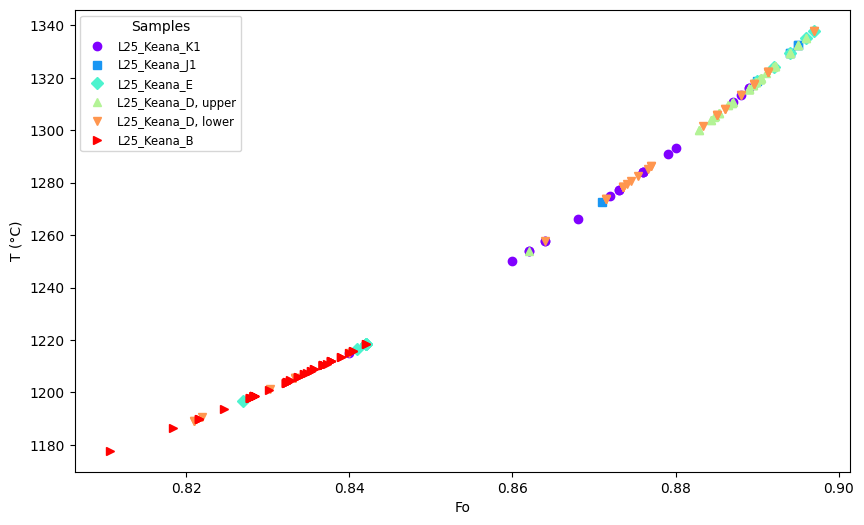

In [10]:
AL25['Fo'] = (pd.to_numeric(AL25['Fo host (olivine Mg#)'], errors='coerce').astype('float64').div(100))
AL25['Temp_from_Fo_all']=Pf_TempFo(AL25['Fo'])
AL25['T_from_Fo_all_is_mean'] = AL25['Temp_from_Fo_all'].isna()
AL25['T_from_Fo_all_is_mean']=AL25['T_from_Fo_all_is_mean']

group_means = AL25.groupby('Sample')['Temp_from_Fo_all'].transform('mean')
AL25.loc[AL25['T_from_Fo_all_is_mean'], 'Temp_from_Fo_all'] = group_means[AL25['T_from_Fo_all_is_mean']]

overall_mean = np.nanmean(AL25['Temp_from_Fo_all'])
AL25['Temp_from_Fo_all'] = AL25['Temp_from_Fo_all'].fillna(overall_mean)

# Create Temp error column, we use 50K +- for now.
AL25['Temp_error'] = 50

####### Now let's plot the Temp vs Fo to visualize the distribution
unique_samples = AL25['Sample'].unique()
colors = plt.cm.rainbow(np.linspace(0, 1, len(unique_samples)))
markers = ['o', 's', 'D', '^', 'v', '>', '<', 'p', '*', 'h', 'H', '+', 'x', 'X']  # List of markers

if len(unique_samples) > len(markers):
    print("Warning: More samples than available marker types; some markers will repeat.")

plt.figure(figsize=(10, 6))

for sample, color, marker in zip(unique_samples, colors, markers * (len(unique_samples) // len(markers) + 1)):
    sample_data = AL25[AL25['Sample'] == sample]
    plt.plot(
        sample_data['Fo'], 
        sample_data['Temp_from_Fo_all'], 
        linestyle='none', 
        marker=marker, 
        label=sample, 
        color=color
    )

plt.xlabel('Fo')
plt.ylabel('T (°C)')

plt.legend(title="Samples", loc="best", fontsize='small')
plt.savefig(figpath+slash+'Temp_vs_Fo_plot_AL25.pdf')
plt.show()

#### Calculate T for K23

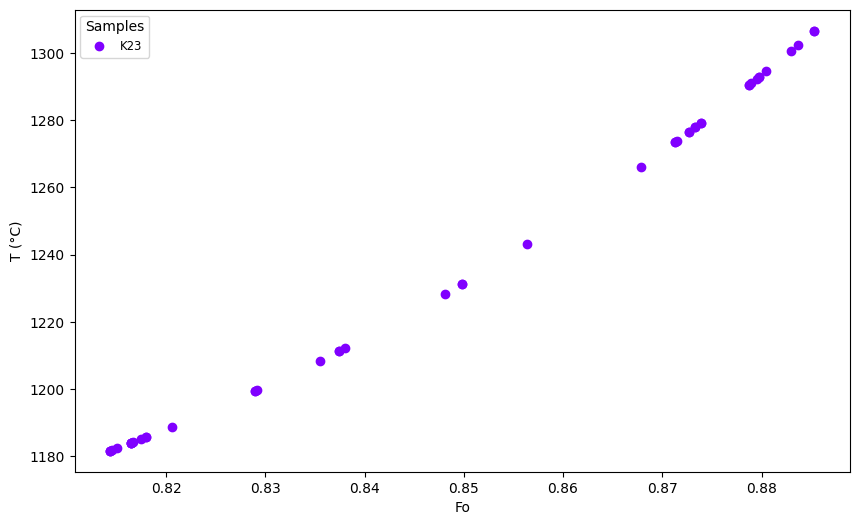

In [11]:
K23['Temp_from_Fo_all']=Pf_TempFo(K23['Fo'])
MeanT=np.nanmean(K23['Temp_from_Fo_all'])
K23['Temp_from_Fo_all'] = K23['Temp_from_Fo_all'].fillna(MeanT)

# Create Temp error column, we use 50K +- for now.
K23['Temp_error'] = np.where(K23['Temp_from_Fo_all'] == MeanT, 50, 50)

####### Now let's plot the Temp vs Fo to visualize the distribution
unique_samples = K23['Sample'].unique()
colors = plt.cm.rainbow(np.linspace(0, 1, len(unique_samples)))
markers = ['o', 's', 'D', '^', 'v', '>', '<', 'p', '*', 'h', 'H', '+', 'x', 'X']  # List of markers

if len(unique_samples) > len(markers):
    print("Warning: More samples than available marker types; some markers will repeat.")

plt.figure(figsize=(10, 6))

for sample, color, marker in zip(unique_samples, colors, markers * (len(unique_samples) // len(markers) + 1)):
    sample_data = K23[K23['Sample'] == sample]
    plt.plot(
        sample_data['Fo'], 
        sample_data['Temp_from_Fo_all'], 
        linestyle='none', 
        marker=marker, 
        label=sample, 
        color=color
    )

plt.xlabel('Fo')
plt.ylabel('T (°C)')

plt.legend(title="Samples", loc="best", fontsize='small')
plt.savefig(figpath+slash+'Temp_vs_Fo_plot_K23.pdf')
plt.show()

#### Calculate T for LERZ2018

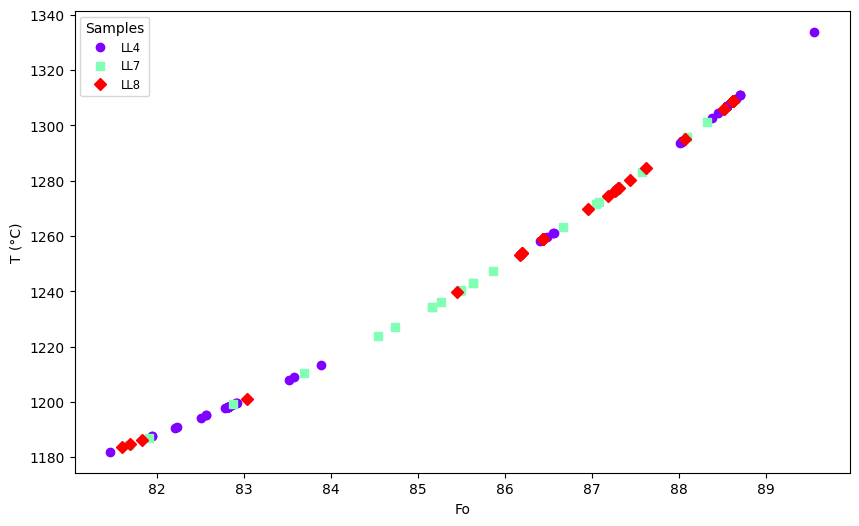

In [12]:
LERZ2018['Temp_from_Fo_all']=Pf_TempFo(LERZ2018['Corrected Fo content (molar %)_Cambridge']/100)
MeanT=np.nanmean(LERZ2018['Temp_from_Fo_all'])
LERZ2018['Temp_from_Fo_all'] = LERZ2018['Temp_from_Fo_all'].fillna(MeanT)

# Create Temp error column, we use 50K +- for now.
LERZ2018['Temp_error'] = np.where(LERZ2018['Temp_from_Fo_all'] == MeanT, 50, 50)

####### Now let's plot the Temp vs Fo to visualize the distribution
unique_samples = LERZ2018['Event ID (LL8 - July, LL7-Aug, LL4-May)'].unique()
colors = plt.cm.rainbow(np.linspace(0, 1, len(unique_samples)))
markers = ['o', 's', 'D', '^', 'v', '>', '<', 'p', '*', 'h', 'H', '+', 'x', 'X']  # List of markers

if len(unique_samples) > len(markers):
    print("Warning: More samples than available marker types; some markers will repeat.")

plt.figure(figsize=(10, 6))

for sample, color, marker in zip(unique_samples, colors, markers * (len(unique_samples) // len(markers) + 1)):
    sample_data = LERZ2018[LERZ2018[ 'Event ID (LL8 - July, LL7-Aug, LL4-May)'] == sample]
    plt.plot(
        sample_data['Corrected Fo content (molar %)_Cambridge'], 
        sample_data['Temp_from_Fo_all'], 
        linestyle='none', 
        marker=marker, 
        label=sample, 
        color=color
    )

plt.xlabel('Fo')
plt.ylabel('T (°C)')

plt.legend(title="Samples", loc="best", fontsize='small')
plt.savefig(figpath+slash+'Temp_vs_Fo_plot_LERZ2018.pdf')
plt.show()

## 5. Calculate the XH2O in the fluid inclusions
- This uses the relationships from DeVitre and Wieser (2024) GPL
- First we import the pickles (min, average, max - see paper for details)
- Then we calculate a first approximation of pressure using pure CO2 EOS, and calculate a first approximation of XH2O from this pressure
- After that we recalculate the pressure using mixed CO2-H2O EOS from Duan and Zhang 2006
- We recalculate XH2O from this new pressure
- We recalculate pressure and XH2O one more time to ensure it has not varied

### A. First, import the pickles (polynomial relationships)

In [13]:
pf_files = ["PXH2O_min.pkl", "PXH2O_max.pkl", "PXH2O_av.pkl"]
Pf_functions = {}

for file_name, label in zip(pf_files, ["Pf_min", "Pf_max", "Pf_av"]):
    with open(os.path.join(MasterFolder+slash+'Data_processing_notebooks', "T and XH2O pickles", file_name), 'rb') as f:
        Pf_functions[label] = pickle.load(f)

Pf_min = Pf_functions["Pf_min"]
Pf_max = Pf_functions["Pf_max"]
Pf_av = Pf_functions["Pf_av"]

# And its defined as XH2O_av=1-Pf_med(P_SW96['P_MPa'])

### B. Calculate the first approximation XH2O

#### First, calculate approximated pressure with pure CO2 EOS

In [14]:
# Make a new CO2 density column in AL25 data that is numeric
AL25['Density g/cm3']=(pd.to_numeric(AL25['CO2 bulk density in vapor bubble (g/cm3)'], errors='coerce').astype('float64'))
# We use only the FLuid inclusion data for the rest
AL25['original_row_index']=AL25.index
# New column for merging later
AL25['Final_merge_column']=AL25['Sample Name\n(melt inclusions and fluid inclusions)'].astype('str')+"_"+AL25['Sample'].astype('str')+"_"+AL25.index.astype('str')

Original_AL25=AL25.copy() ## For safekeeping the original frame

AL25=AL25[(AL25['FI or MI (>80% VB is FI)']=='FI')&(AL25['Density g/cm3'].isna()==False)].copy()

AL25.head()

,Sample Name\n(melt inclusions and fluid inclusions),Keanakākoʻi Tephra unit name\n(Swanson & Houghton 2018 nomenclature),Sample,Keanakākoʻi Tephra unit description,Eruption Date (CE),Sample Site: Latitude (WGS84),Sample Site: Longitude (WGS84),Inclusion type,Inclusion notes,Sulfide diameter (um)\nif present in melt inclusion,...,Saturation depth (km) from Shishina et al 2014 sat. pressure,Recalculations for Pre-Post Caldera paper >,FI or MI (>80% VB is FI),Fo,Temp_from_Fo_all,T_from_Fo_all_is_mean,Temp_error,Density g/cm3,original_row_index,Final_merge_column
78,K99-5_1b,"D, upper","L25_Keana_D, upper",vitric ash 2A2,1500-1650,19.38981,-155.29229,bubble-dom MI,Bubble is likely a co-trapped exsolved fluid p...,no sulfide,...,-,NaN,FI,0.892203,1324.598452,False,50,0.140730,78,"K99-5_1b_L25_Keana_D, upper_78"
79,K99-5_1c,"D, upper","L25_Keana_D, upper",vitric ash 2A2,1500-1650,19.38981,-155.29229,fluid inclusion,Isolated fluid inclusion,-,...,-,NaN,FI,0.892203,1324.598452,False,50,0.136896,79,"K99-5_1c_L25_Keana_D, upper_79"
83,K99-5_4a,"D, upper","L25_Keana_D, upper",vitric ash 2A2,1500-1650,19.38981,-155.29229,fluid inclusion,Isolated fluid inclusion,-,...,-,NaN,FI,0.891111,1321.648111,False,50,0.134615,83,"K99-5_4a_L25_Keana_D, upper_83"
84,K99-5_4b,"D, upper","L25_Keana_D, upper",vitric ash 2A2,1500-1650,19.38981,-155.29229,fluid inclusion,Isolated fluid inclusion,-,...,-,NaN,FI,0.889820,1318.202238,False,50,0.130126,84,"K99-5_4b_L25_Keana_D, upper_84"
85,K99-5_4c,"D, upper","L25_Keana_D, upper",vitric ash 2A2,1500-1650,19.38981,-155.29229,fluid inclusion,Isolated fluid inclusion,-,...,-,NaN,FI,0.889820,1318.202238,False,50,0.135428,85,"K99-5_4c_L25_Keana_D, upper_85"


In [15]:
# Now calculate
AL25.reset_index(drop=True, inplace=True)
AL25['P_kbar_pureCO2_firstapprox'] =pf.calculate_P_for_rho_T(CO2_dens_gcm3=AL25['Density g/cm3'],
                                                                        T_K=AL25['Temp_from_Fo_all'] + 273.15,
                                                                        EOS='SW96')['P_kbar']
# Then K23 and LERZ
K23['P_kbar_pureCO2_firstapprox'] =pf.calculate_P_for_rho_T(CO2_dens_gcm3=K23['Density g/cm3'],
                                                                        T_K=K23['Temp_from_Fo_all'] + 273.15,
                                                                        EOS='SW96')['P_kbar']

LERZ2018['P_kbar_pureCO2_firstapprox'] =pf.calculate_P_for_rho_T(CO2_dens_gcm3=LERZ2018['Density g/cm3'],
                                                                        T_K=LERZ2018['Temp_from_Fo_all'] + 273.15,
                                                                        EOS='SW96')['P_kbar']

display(AL25.head())
display(K23.head())
display(LERZ2018.head())

,Sample Name\n(melt inclusions and fluid inclusions),Keanakākoʻi Tephra unit name\n(Swanson & Houghton 2018 nomenclature),Sample,Keanakākoʻi Tephra unit description,Eruption Date (CE),Sample Site: Latitude (WGS84),Sample Site: Longitude (WGS84),Inclusion type,Inclusion notes,Sulfide diameter (um)\nif present in melt inclusion,...,Recalculations for Pre-Post Caldera paper >,FI or MI (>80% VB is FI),Fo,Temp_from_Fo_all,T_from_Fo_all_is_mean,Temp_error,Density g/cm3,original_row_index,Final_merge_column,P_kbar_pureCO2_firstapprox
0,K99-5_1b,"D, upper","L25_Keana_D, upper",vitric ash 2A2,1500-1650,19.38981,-155.29229,bubble-dom MI,Bubble is likely a co-trapped exsolved fluid p...,no sulfide,...,NaN,FI,0.892203,1324.598452,False,50,0.140730,78,"K99-5_1b_L25_Keana_D, upper_78",0.471083
1,K99-5_1c,"D, upper","L25_Keana_D, upper",vitric ash 2A2,1500-1650,19.38981,-155.29229,fluid inclusion,Isolated fluid inclusion,-,...,NaN,FI,0.892203,1324.598452,False,50,0.136896,79,"K99-5_1c_L25_Keana_D, upper_79",0.456869
2,K99-5_4a,"D, upper","L25_Keana_D, upper",vitric ash 2A2,1500-1650,19.38981,-155.29229,fluid inclusion,Isolated fluid inclusion,-,...,NaN,FI,0.891111,1321.648111,False,50,0.134615,83,"K99-5_4a_L25_Keana_D, upper_83",0.447581
3,K99-5_4b,"D, upper","L25_Keana_D, upper",vitric ash 2A2,1500-1650,19.38981,-155.29229,fluid inclusion,Isolated fluid inclusion,-,...,NaN,FI,0.889820,1318.202238,False,50,0.130126,84,"K99-5_4b_L25_Keana_D, upper_84",0.430164
4,K99-5_4c,"D, upper","L25_Keana_D, upper",vitric ash 2A2,1500-1650,19.38981,-155.29229,fluid inclusion,Isolated fluid inclusion,-,...,NaN,FI,0.889820,1318.202238,False,50,0.135428,85,"K99-5_4c_L25_Keana_D, upper_85",0.449545


,Column headers,py_index,Crystal Name,FI Name,Reported density mean of reps?,Density g/cm3,"σ Density g/cm3 (as plotted, from DiadFit for individual, Std dev for averaged FI)",STDofreps_Density g/cm3,σ Density g/cm3 (DiadFit),σ Density g/cm3 (from Ne+peakfit),...,spinel,sulfide,shape,Comment,Recalculations for Pre-Post Caldera paper >,Sample,SO2 mol%_recalculated,Temp_from_Fo_all,Temp_error,P_kbar_pureCO2_firstapprox
0,NaN,0,K23_101,K23_101_FIC,No,0.085665,0.007736,NaN,0.007736,0.006738,...,NaN,NaN,NaN,NaN,NaN,K23,-0.309044,1292.655593,50,0.269230
1,NaN,1,K23_101,K23_101_FID,No,0.100137,0.005037,NaN,0.005037,0.003301,...,NaN,NaN,NaN,NaN,NaN,K23,1.699992,1292.655593,50,0.318108
2,NaN,2,K23_102,K23_102_FIA,No,0.112454,0.004482,NaN,0.004482,0.002350,...,NaN,NaN,NaN,NaN,NaN,K23,NaN,1290.946549,50,0.360147
3,NaN,3,K23_10,K23_10_FIA,No,0.131039,0.004066,NaN,0.004066,0.001310,...,NaN,NaN,NaN,NaN,NaN,K23,4.781801,1238.332018,50,0.410571
4,NaN,4,K23_1,K23_1_FIA,Yes,0.142919,0.002579,0.002579,0.003950,0.000744,...,NaN,NaN,NaN,NaN,NaN,K23,NaN,1265.953462,50,0.460648


,Py_index,Event Description,"Event ID (LL8 - July, LL7-Aug, LL4-May)",Host crystal ID,Fluid inclusion ID,Raman Data >,Fermi Diad separation ΔCO2 (cm-1),Corrected ΔCO2 (cm-1),Corrected ΔCO2 1σ (cm-1),CO2 density (g/cm3),...,"Shishkina Saturation pressure Min CO2 (glass+bubble, PEC corr,-1 sigma splitting -1 sigmabubble vol)",Shishkina Saturation pressure (Glass only CO2),Shishkina Saturation pressure (EOS method - glass+ reconstructed bubble),Recalculations for Pre-Post Caldera paper >,Eruption,Density g/cm3,SO2 mol%_recalculated,Temp_from_Fo_all,Temp_error,P_kbar_pureCO2_firstapprox
0,0,"LERZ, Fissure 8, May 30th 2018",LL4,LL4-14dp,LL4-14dp-FI#1,ν1 refers to the low wavenumber band of the fe...,103.416763,103.186144,0.006461,0.176605,...,NaN,NaN,NaN,NaN,LERZ2018,0.176605,4.088172,1259.723187,50,0.582127
1,1,"LERZ, Fissure 8, May 30th 2018",LL4,LL4-14dp,LL4-14dp-FI#2,NaN,103.431244,103.195894,0.007137,0.180578,...,NaN,NaN,NaN,NaN,LERZ2018,0.180578,2.406601,1258.065163,50,0.596455
2,2,"LERZ, Fissure 8, May 30th 2018",LL4,LL4-14dp,LL4-14dp-MI#1,NaN,103.429713,103.196578,0.010404,0.180858,...,NaN,NaN,NaN,NaN,LERZ2018,0.180858,6.492751,1261.215617,50,0.598838
3,3,"LERZ, Fissure 8, May 30th 2018",LL4,LL4-21,LL4-21-#2,NaN,103.379425,103.122405,0.001766,0.147317,...,NaN,NaN,NaN,NaN,LERZ2018,0.147317,NaN,1213.468027,50,0.459202
4,7,"LERZ, Fissure 8, May 30th 2018",LL4,LL4-21,LL4-21-MI#5,NaN,103.170121,102.953345,0.007431,0.080378,...,NaN,NaN,NaN,NaN,LERZ2018,0.080378,NaN,1261.058075,50,0.246376


#### Next, we calculate the XH2O first approximation

In [16]:
# Create function to calculate XH2O from pickles that were loaded,
# If XH2O is negative we assign 0 to it
def calculate_XH2O(P_kbar, Pf_func):
    XH2O = 1 - Pf_func(P_kbar * 100)
    XH2O[XH2O < 0] = 0
    return XH2O

AL25['XH2O_av_firstapprox'] = calculate_XH2O(AL25['P_kbar_pureCO2_firstapprox'], Pf_av)
AL25['XH2O_min_firstapprox'] = calculate_XH2O(AL25['P_kbar_pureCO2_firstapprox'], Pf_min)
AL25['XH2O_max_firstapprox'] = calculate_XH2O(AL25['P_kbar_pureCO2_firstapprox'], Pf_max)

K23['XH2O_av_firstapprox'] = calculate_XH2O(K23['P_kbar_pureCO2_firstapprox'], Pf_av)
K23['XH2O_min_firstapprox'] = calculate_XH2O(K23['P_kbar_pureCO2_firstapprox'], Pf_min)
K23['XH2O_max_firstapprox'] = calculate_XH2O(K23['P_kbar_pureCO2_firstapprox'], Pf_max)

LERZ2018['XH2O_av_firstapprox'] = calculate_XH2O(LERZ2018['P_kbar_pureCO2_firstapprox'], Pf_av)
LERZ2018['XH2O_min_firstapprox'] = calculate_XH2O(LERZ2018['P_kbar_pureCO2_firstapprox'], Pf_min)
LERZ2018['XH2O_max_firstapprox'] = calculate_XH2O(LERZ2018['P_kbar_pureCO2_firstapprox'], Pf_max)

### C. Now, we iterate calculations using mixed H2O-CO2 EOS of Duan and Zhang
- We do 3 iterations: this means P, XH2O; P2, XH2O2;P3, XH2O final

In [17]:
def calculate_entrapment_pressure(df, XH2O_col):
    return pf.calculate_entrapment_P_XH2O(
        XH2O=df[XH2O_col],
        CO2_dens_gcm3=df['Density g/cm3'],
        T_K=df['Temp_from_Fo_all'] + 273.15,
        T_K_ambient=37 + 273.15,
        fast_calcs=False,
        Hloss=True
    )['P_kbar_mixCO2_DZ06_no_Hloss']

#### First, let's do Lerner 2025 (AL25)

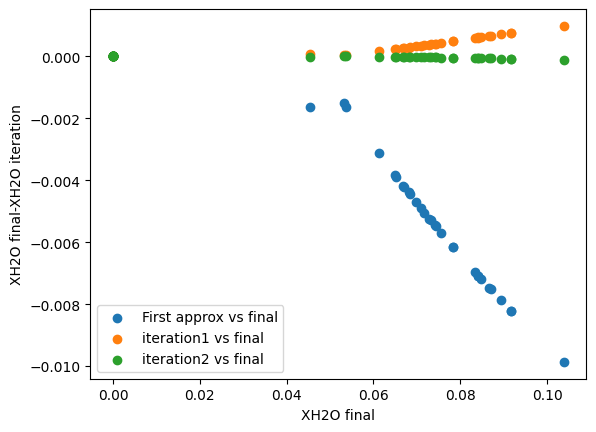

In [18]:
# Then we iterate 3 times to get the final XH2O
for i in range(1, 4):
    if i == 1:
        suffix = '_firstapprox'
    else:
        suffix = f'_iteration{i - 1}'
        
    # Calculate pressures
    AL25[f'P_kbar_mixCO2_DZ06_no_Hloss_av_iteration{i}'] = calculate_entrapment_pressure(AL25, f'XH2O_av{suffix}').to_numpy()
    AL25[f'P_kbar_mixCO2_DZ06_no_Hloss_min_iteration{i}'] = calculate_entrapment_pressure(AL25, f'XH2O_min{suffix}').to_numpy()
    AL25[f'P_kbar_mixCO2_DZ06_no_Hloss_max_iteration{i}'] = calculate_entrapment_pressure(AL25, f'XH2O_max{suffix}').to_numpy()

    # Calculate XH2O
    AL25[f'XH2O_av_iteration{i}{"" if i < 3 else "_final"}'] = calculate_XH2O(AL25[f'P_kbar_mixCO2_DZ06_no_Hloss_av_iteration{i}'], Pf_av)
    AL25[f'XH2O_min_iteration{i}{"" if i < 3 else "_final"}'] = calculate_XH2O(AL25[f'P_kbar_mixCO2_DZ06_no_Hloss_min_iteration{i}'], Pf_min)
    AL25[f'XH2O_max_iteration{i}{"" if i < 3 else "_final"}'] = calculate_XH2O(AL25[f'P_kbar_mixCO2_DZ06_no_Hloss_max_iteration{i}'], Pf_max)


plt.scatter(AL25['XH2O_av_iteration3_final'],AL25['XH2O_av_iteration3_final']-AL25['XH2O_av_firstapprox'],label='First approx vs final')
plt.scatter(AL25['XH2O_av_iteration3_final'],AL25['XH2O_av_iteration3_final']-AL25['XH2O_av_iteration1'],label='iteration1 vs final')
plt.scatter(AL25['XH2O_av_iteration3_final'],AL25['XH2O_av_iteration3_final']-AL25['XH2O_av_iteration2'],label='iteration2 vs final')
plt.xlabel("XH2O final")
plt.ylabel("XH2O final-XH2O iteration")
plt.legend()
plt.savefig(figpath+slash+'XH2O_iteration_AL25.pdf')

#### Then, let's do K23

,Column headers,py_index,Crystal Name,FI Name,Reported density mean of reps?,Density g/cm3,"σ Density g/cm3 (as plotted, from DiadFit for individual, Std dev for averaged FI)",STDofreps_Density g/cm3,σ Density g/cm3 (DiadFit),σ Density g/cm3 (from Ne+peakfit),...,P_kbar_mixCO2_DZ06_no_Hloss_max_iteration2,XH2O_av_iteration2,XH2O_min_iteration2,XH2O_max_iteration2,P_kbar_mixCO2_DZ06_no_Hloss_av_iteration3,P_kbar_mixCO2_DZ06_no_Hloss_min_iteration3,P_kbar_mixCO2_DZ06_no_Hloss_max_iteration3,XH2O_av_iteration3_final,XH2O_min_iteration3_final,XH2O_max_iteration3_final
0,NaN,0,K23_101,K23_101_FIC,No,0.085665,0.007736,NaN,0.007736,0.006738,...,0.315446,0.108354,0.053667,0.161712,0.299401,0.283126,0.317289,0.108233,0.053662,0.160818
1,NaN,1,K23_101,K23_101_FID,No,0.100137,0.005037,NaN,0.005037,0.003301,...,0.364269,0.093936,0.046393,0.140256,0.348230,0.331990,0.365749,0.093852,0.046389,0.139676
2,NaN,2,K23_102,K23_102_FIA,No,0.112454,0.004482,NaN,0.004482,0.002350,...,0.406088,0.083813,0.041187,0.125326,0.390018,0.373856,0.407247,0.083756,0.041184,0.124954
3,NaN,3,K23_10,K23_10_FIA,No,0.131039,0.004066,NaN,0.004066,0.001310,...,0.456324,0.074056,0.036058,0.111089,0.440142,0.424042,0.457133,0.074023,0.036056,0.110889
4,NaN,4,K23_1,K23_1_FIA,Yes,0.142919,0.002579,0.002579,0.003950,0.000744,...,0.506552,0.066586,0.032022,0.100329,0.490051,0.473817,0.507087,0.066568,0.032021,0.100231


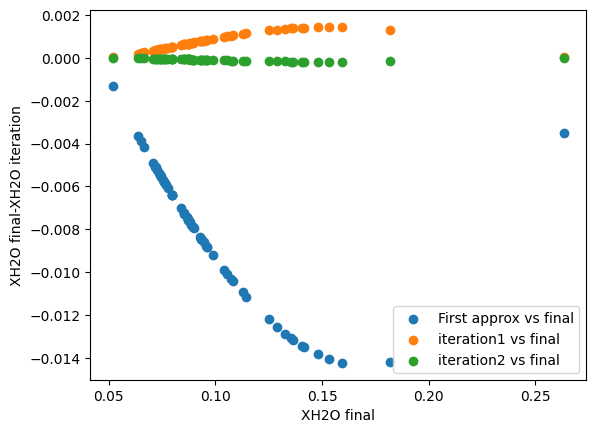

In [19]:
# Then we iterate 3 times to get the final XH2O
for i in range(1, 4):
    if i == 1:
        suffix = '_firstapprox'
    else:
        suffix = f'_iteration{i - 1}'

    # Calculate pressures
    K23[f'P_kbar_mixCO2_DZ06_no_Hloss_av_iteration{i}'] = calculate_entrapment_pressure(K23, f'XH2O_av{suffix}')
    K23[f'P_kbar_mixCO2_DZ06_no_Hloss_min_iteration{i}'] = calculate_entrapment_pressure(K23, f'XH2O_min{suffix}')
    K23[f'P_kbar_mixCO2_DZ06_no_Hloss_max_iteration{i}'] = calculate_entrapment_pressure(K23, f'XH2O_max{suffix}')

    # Calculate XH2O
    K23[f'XH2O_av_iteration{i}{"" if i < 3 else "_final"}'] = calculate_XH2O(K23[f'P_kbar_mixCO2_DZ06_no_Hloss_av_iteration{i}'], Pf_av)
    K23[f'XH2O_min_iteration{i}{"" if i < 3 else "_final"}'] = calculate_XH2O(K23[f'P_kbar_mixCO2_DZ06_no_Hloss_min_iteration{i}'], Pf_min)
    K23[f'XH2O_max_iteration{i}{"" if i < 3 else "_final"}'] = calculate_XH2O(K23[f'P_kbar_mixCO2_DZ06_no_Hloss_max_iteration{i}'], Pf_max)


plt.scatter(K23['XH2O_av_iteration3_final'],K23['XH2O_av_iteration3_final']-K23['XH2O_av_firstapprox'],label='First approx vs final')
plt.scatter(K23['XH2O_av_iteration3_final'],K23['XH2O_av_iteration3_final']-K23['XH2O_av_iteration1'],label='iteration1 vs final')
plt.scatter(K23['XH2O_av_iteration3_final'],K23['XH2O_av_iteration3_final']-K23['XH2O_av_iteration2'],label='iteration2 vs final')
plt.xlabel("XH2O final")
plt.ylabel("XH2O final-XH2O iteration")
plt.legend()
plt.savefig(figpath+slash+'XH2O_iteration_K23.pdf')

K23.head()

#### Next, Let's do LERZ 2018

,Py_index,Event Description,"Event ID (LL8 - July, LL7-Aug, LL4-May)",Host crystal ID,Fluid inclusion ID,Raman Data >,Fermi Diad separation ΔCO2 (cm-1),Corrected ΔCO2 (cm-1),Corrected ΔCO2 1σ (cm-1),CO2 density (g/cm3),...,P_kbar_mixCO2_DZ06_no_Hloss_max_iteration2,XH2O_av_iteration2,XH2O_min_iteration2,XH2O_max_iteration2,P_kbar_mixCO2_DZ06_no_Hloss_av_iteration3,P_kbar_mixCO2_DZ06_no_Hloss_min_iteration3,P_kbar_mixCO2_DZ06_no_Hloss_max_iteration3,XH2O_av_iteration3_final,XH2O_min_iteration3_final,XH2O_max_iteration3_final
0,0,"LERZ, Fissure 8, May 30th 2018",LL4,LL4-14dp,LL4-14dp-FI#1,ν1 refers to the low wavenumber band of the fe...,103.416763,103.186144,0.006461,0.176605,...,0.630592,0.055468,0.025619,0.084859,0.612461,0.595016,0.630743,0.055466,0.025618,0.084847
1,1,"LERZ, Fissure 8, May 30th 2018",LL4,LL4-14dp,LL4-14dp-FI#2,NaN,103.431244,103.195894,0.007137,0.180578,...,0.645442,0.054645,0.025107,0.083762,0.627037,0.609360,0.645571,0.054643,0.025107,0.083753
2,2,"LERZ, Fissure 8, May 30th 2018",LL4,LL4-14dp,LL4-14dp-MI#1,NaN,103.429713,103.196578,0.010404,0.180858,...,0.647914,0.054516,0.025026,0.083590,0.629460,0.611740,0.648040,0.054514,0.025026,0.083582
3,3,"LERZ, Fissure 8, May 30th 2018",LL4,LL4-21,LL4-21-#2,NaN,103.379425,103.122405,0.001766,0.147317,...,0.505081,0.066771,0.032121,0.100600,0.488630,0.472438,0.505619,0.066753,0.032120,0.100501
4,7,"LERZ, Fissure 8, May 30th 2018",LL4,LL4-21,LL4-21-MI#5,NaN,103.170121,102.953345,0.007431,0.080378,...,0.292426,0.116203,0.057567,0.173480,0.276393,0.260178,0.294407,0.116065,0.057561,0.172423


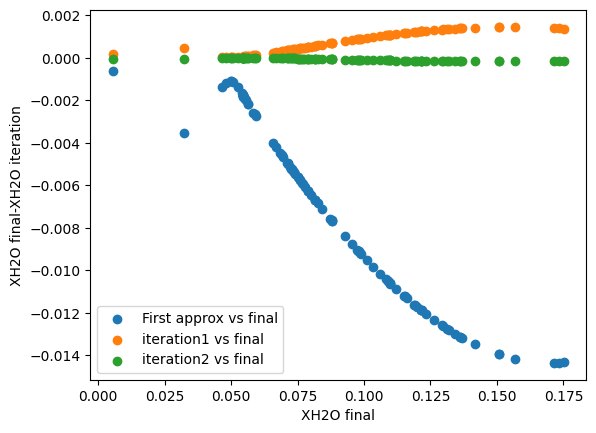

In [20]:
# Then we iterate 3 times to get the final XH2O
for i in range(1, 4):
    if i == 1:
        suffix = '_firstapprox'
    else:
        suffix = f'_iteration{i - 1}'

    # Calculate pressures
    LERZ2018[f'P_kbar_mixCO2_DZ06_no_Hloss_av_iteration{i}'] = calculate_entrapment_pressure(LERZ2018, f'XH2O_av{suffix}')
    LERZ2018[f'P_kbar_mixCO2_DZ06_no_Hloss_min_iteration{i}'] = calculate_entrapment_pressure(LERZ2018, f'XH2O_min{suffix}')
    LERZ2018[f'P_kbar_mixCO2_DZ06_no_Hloss_max_iteration{i}'] = calculate_entrapment_pressure(LERZ2018, f'XH2O_max{suffix}')

    # Calculate XH2O
    LERZ2018[f'XH2O_av_iteration{i}{"" if i < 3 else "_final"}'] = calculate_XH2O(LERZ2018[f'P_kbar_mixCO2_DZ06_no_Hloss_av_iteration{i}'], Pf_av)
    LERZ2018[f'XH2O_min_iteration{i}{"" if i < 3 else "_final"}'] = calculate_XH2O(LERZ2018[f'P_kbar_mixCO2_DZ06_no_Hloss_min_iteration{i}'], Pf_min)
    LERZ2018[f'XH2O_max_iteration{i}{"" if i < 3 else "_final"}'] = calculate_XH2O(LERZ2018[f'P_kbar_mixCO2_DZ06_no_Hloss_max_iteration{i}'], Pf_max)


plt.scatter(LERZ2018['XH2O_av_iteration3_final'],LERZ2018['XH2O_av_iteration3_final']-LERZ2018['XH2O_av_firstapprox'],label='First approx vs final')
plt.scatter(LERZ2018['XH2O_av_iteration3_final'],LERZ2018['XH2O_av_iteration3_final']-LERZ2018['XH2O_av_iteration1'],label='iteration1 vs final')
plt.scatter(LERZ2018['XH2O_av_iteration3_final'],LERZ2018['XH2O_av_iteration3_final']-LERZ2018['XH2O_av_iteration2'],label='iteration2 vs final')
plt.xlabel("XH2O final")
plt.ylabel("XH2O final-XH2O iteration")
plt.legend()
plt.savefig(figpath+slash+'XH2O_iteration_LERZ2018.pdf')

LERZ2018.head()

## 6. Calculate final pressure and depth, propagate uncertainty and remerge

### A. Calculate final pressure and depth and propagate uncertainty using Monte Carlo simulation
- 500 duplicates
- Duan and Zhang (2006) EOS for mixed H2O-CO2 fluids
- CO2 density from Raman (error is sigma from DiadFit if not mean measurement, else it's standard deviation; absolute and normally distributed)
- XH2O is used from previous step (XH2O error as the half difference between min and max XH2O, absolute and normally distributed)
- Temperature from Forsterite content of host, or the mean of whole dataset when not available (Temperature error of +- 50K, absolute and normally distributed)
- Denlinger-lerner crustal model in DiadFit. 

#### First, let's do Lerner 2025

You have entered a value for XH2O, so we are now using the EOS of Duan and Zhang 200 regardless of what model you selected. If you dont want this, specify XH2O=None
Please note, the DZ2006 EOS is about 5-40X slower to run than the SP94 and SW94 EOS
We are using multiprocessing based on your selected EOS. You can override this by setting multiprocess=False in the function, but it might slow it down a lot
Number of processors:  10


,Filename,i,CO2_density_input,SingleCalc_D_km,SingleCalc_P_kbar,Mean_MC_P_kbar,Med_MC_P_kbar,std_dev_MC_P_kbar,std_dev_MC_P_kbar_from_percentile,Mean_MC_D_km,...,T_K_input,error_T_K,CO2_dens_gcm3_input,error_CO2_dens_gcm3,crust_dens_kgm3_input,error_crust_dens_kgm3,model,EOS,XH2O_input,error_XH2O
0,"L25_Keana_D, upper_78",0.0,0.140730,2.128561,0.502540,0.505796,0.503722,0.025645,0.023538,2.141377,...,1597.748452,50.0,0.140730,2.520580e-03,None,0.0,denlinger_lerner,DZ06,0.065282,0.033555
1,"L25_Keana_D, upper_79",1.0,0.136896,2.071135,0.488270,0.491608,0.489743,0.026343,0.025466,2.084304,...,1597.748452,50.0,0.136896,3.129707e-03,None,0.0,denlinger_lerner,DZ06,0.067087,0.034336
2,"L25_Keana_D, upper_83",2.0,0.134615,2.033643,0.478975,0.482614,0.480813,0.030625,0.028731,2.047951,...,1594.798111,50.0,0.134615,5.130975e-03,None,0.0,denlinger_lerner,DZ06,0.068346,0.034886
3,"L25_Keana_D, upper_84",3.0,0.130126,1.963244,0.461568,0.464613,0.462689,0.023205,0.021559,1.975355,...,1591.352238,50.0,0.130126,1.281845e-03,None,0.0,denlinger_lerner,DZ06,0.070886,0.036008
4,"L25_Keana_D, upper_85",4.0,0.135428,2.041719,0.480976,0.483921,0.482475,0.023185,0.022118,2.053387,...,1591.352238,50.0,0.135428,5.703231e-04,None,0.0,denlinger_lerner,DZ06,0.068070,0.034763
5,"L25_Keana_D, upper_86",5.0,0.125965,1.901997,0.446474,0.449750,0.448363,0.025003,0.023668,1.915049,...,1591.352238,50.0,0.125965,2.861809e-03,None,0.0,denlinger_lerner,DZ06,0.073292,0.037087
6,"L25_Keana_D, upper_87",6.0,0.355002,5.580116,1.433496,1.457124,1.447086,0.278742,0.264944,5.646552,...,1592.592252,50.0,0.355002,5.037819e-02,None,0.0,denlinger_lerner,DZ06,0.000000,0.000000
7,"L25_Keana_D, upper_88",7.0,0.398999,6.449470,1.688618,1.707187,1.698141,0.237428,0.225611,6.503725,...,1592.592252,50.0,0.398999,3.847903e-02,None,0.0,denlinger_lerner,DZ06,0.000000,0.000000
8,"L25_Keana_D, upper_89",8.0,0.322044,4.965306,1.257553,1.312794,1.285332,0.461547,0.435176,5.114449,...,1592.592252,50.0,0.322044,8.764808e-02,None,0.0,denlinger_lerner,DZ06,0.000000,0.000000
9,"L25_Keana_D, upper_90",9.0,0.470819,8.071432,2.179446,2.243943,2.211543,0.588689,0.559909,8.274966,...,1592.592252,50.0,0.470819,8.036363e-02,None,0.0,denlinger_lerner,DZ06,0.000000,0.000000


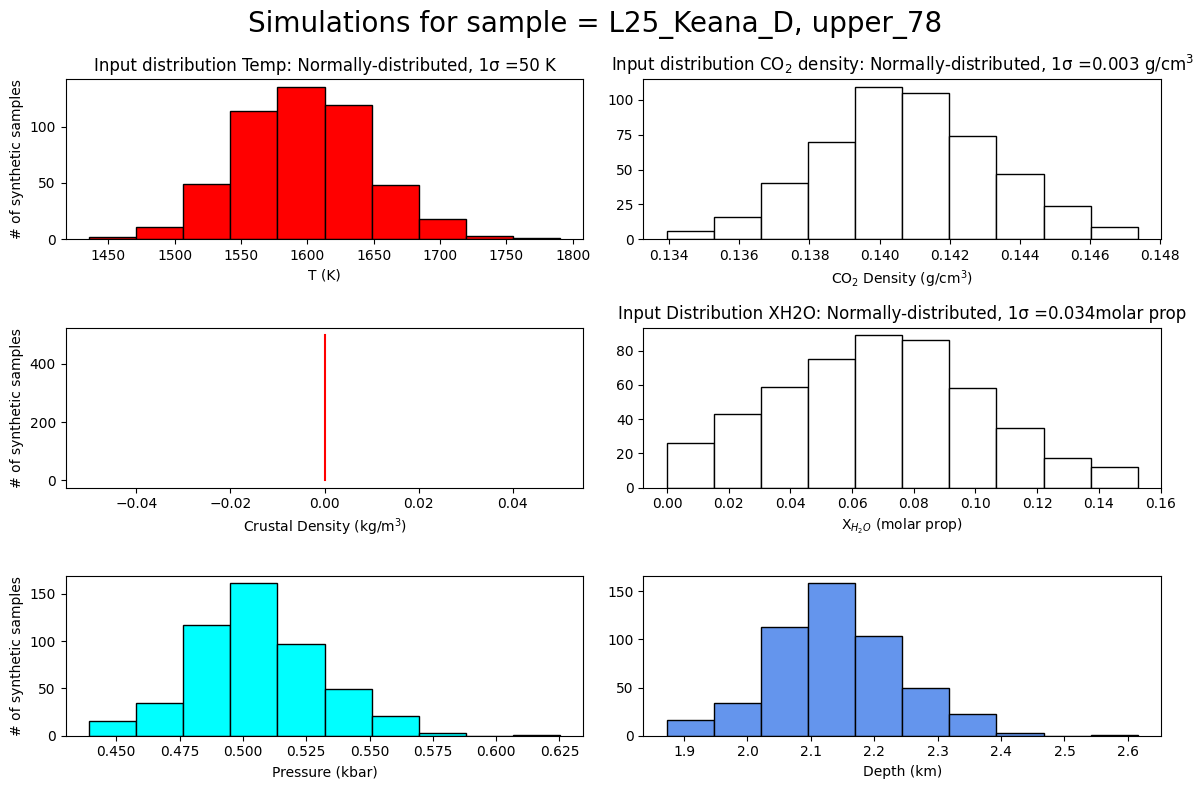

In [185]:
# ## Before doing this, to ensure proper merging we have to create a new column in K23
AL25['MCSim_filename(_date_secsincemidnight)']=AL25['Sample']+"_"+AL25['original_row_index'].astype("str")

# ## We also create a new column with the CO2 density error, 
# ## if the measurement was averaged, the error is the standard deviation ('Density g/cm3_Raman_STD') 
# ## if it's microtherm or raman, it's the corresponding error reported
AL25['± CO2 bulk density 1σ uncertainty (g/cm3)']=(pd.to_numeric(AL25['± CO2 bulk density 1σ uncertainty (g/cm3)'], errors='coerce').astype('float64'))
AL25['± CO2 Fermi diad 1SE uncertainty,  ∆ (cm-1)']=(pd.to_numeric(AL25['± CO2 Fermi diad 1SE uncertainty,  ∆ (cm-1)'], errors='coerce').astype('float64'))

AL25['error_CO2_dens_STDifmean_σifnot'] = np.where(
    AL25['± CO2 bulk density 1σ uncertainty (g/cm3)'].notna(),
    AL25['± CO2 bulk density 1σ uncertainty (g/cm3)'],
    pd.NA
)

## Now run the simulations
AL25_MC_Av_rho_T_df_B, AL25_MC_All_rho_T_df_B, AL25_fig=pf.propagate_FI_uncertainty(
T_K=AL25['Temp_from_Fo_all']+273.15,
error_T_K=AL25['Temp_error'], error_type_T_K='Abs', error_dist_T_K='normal',
CO2_dens_gcm3=AL25['Density g/cm3'],error_CO2_dens=AL25['error_CO2_dens_STDifmean_σifnot'], 
error_type_CO2_dens='Abs', error_dist_CO2_dens='normal',
XH2O=AL25['XH2O_av_iteration3_final'], error_XH2O=pd.Series(0.5*np.abs(AL25['XH2O_max_iteration3_final']-AL25['XH2O_min_iteration3_final'])), error_type_XH2O='Abs', error_dist_XH2O='normal',
sample_ID=AL25['MCSim_filename(_date_secsincemidnight)'],
model='denlinger_lerner',
N_dup=500, fig_i=0, plot_figure=True)

AL25_fig.savefig(figpath+slash+'MCsimulation_AL25.pdf')
AL25_MC_Av_rho_T_df_B

#### Next, let's do K23

You have entered a value for XH2O, so we are now using the EOS of Duan and Zhang 200 regardless of what model you selected. If you dont want this, specify XH2O=None
Please note, the DZ2006 EOS is about 5-40X slower to run than the SP94 and SW94 EOS
We are using multiprocessing based on your selected EOS. You can override this by setting multiprocess=False in the function, but it might slow it down a lot
Number of processors:  10


,Filename,i,CO2_density_input,SingleCalc_D_km,SingleCalc_P_kbar,Mean_MC_P_kbar,Med_MC_P_kbar,std_dev_MC_P_kbar,std_dev_MC_P_kbar_from_percentile,Mean_MC_D_km,...,T_K_input,error_T_K,CO2_dens_gcm3_input,error_CO2_dens_gcm3,crust_dens_kgm3_input,error_crust_dens_kgm3,model,EOS,XH2O_input,error_XH2O
0,"K23_101_FIC_September 20, 2023\n_61092",0.0,0.085665,1.300812,0.300725,0.305054,0.303624,0.035554,0.033614,1.318375,...,1565.805593,50.0,0.085665,0.007736,None,0.0,denlinger_lerner,DZ06,0.108233,0.053578
1,"K23_101_FID_September 20, 2023\n_60805",1.0,0.100137,1.505253,0.349799,0.353519,0.351641,0.028340,0.026415,1.520319,...,1565.805593,50.0,0.100137,0.005037,None,0.0,denlinger_lerner,DZ06,0.093852,0.046643
2,"K23_102_FIA_September 20, 2023\n_61894",2.0,0.112454,1.678540,0.391789,0.395317,0.393526,0.027480,0.026097,1.692712,...,1564.096549,50.0,0.112454,0.004482,None,0.0,denlinger_lerner,DZ06,0.083756,0.041885
3,"K23_10_FIA_September 20, 2023\n_51932",3.0,0.131039,1.884707,0.442221,0.445626,0.444066,0.027408,0.026307,1.898245,...,1511.482018,50.0,0.131039,0.004066,None,0.0,denlinger_lerner,DZ06,0.074023,0.037417
4,"K23_1_FIA_September 20, 2023\n_52502",4.0,0.142919,2.087512,0.492336,0.495508,0.493439,0.025810,0.023844,2.100015,...,1539.103462,50.0,0.142919,0.002579,None,0.0,denlinger_lerner,DZ06,0.066568,0.034105
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
57,"K23_316_FIA_September 22, 2023\n_42600",57.0,0.101449,1.475617,0.342654,0.345229,0.346158,0.062772,0.063345,1.484610,...,1511.482018,50.0,0.101449,0.015256,None,0.0,denlinger_lerner,DZ06,0.095781,0.047571
58,"K23_316_FIB_September 22, 2023\n_42816",58.0,0.111436,1.612691,0.375790,0.377839,0.375977,0.033941,0.036313,1.620649,...,1511.482018,50.0,0.111436,0.006603,None,0.0,denlinger_lerner,DZ06,0.087392,0.043594
59,"K23_316_FIC_September 22, 2023\n_42443",59.0,0.112573,1.628344,0.379589,0.381642,0.380179,0.034859,0.037325,1.636289,...,1511.482018,50.0,0.112573,0.006891,None,0.0,denlinger_lerner,DZ06,0.086507,0.043178
60,"K23_318_FIA_September 21, 2023\n_63579",60.0,0.091195,1.335461,0.309007,0.309527,0.307652,0.031456,0.031068,1.337203,...,1511.482018,50.0,0.091195,0.007105,None,0.0,denlinger_lerner,DZ06,0.105613,0.052311


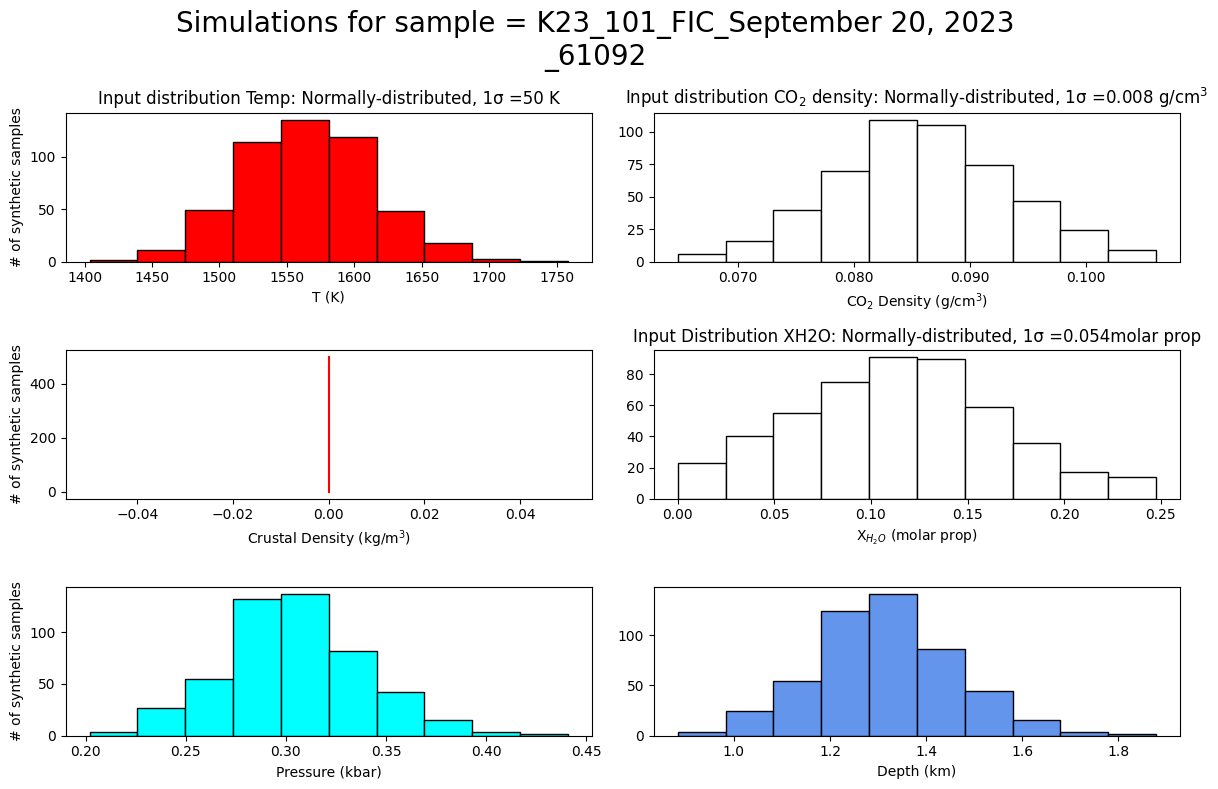

In [186]:
# ## Before doing this, to ensure proper merging we have to create a new column in K23
K23['MCSim_filename(_date_secsincemidnight)']=K23['FI Name']+"_"+K23['date'].astype('str')+"_"+K23['sec since midnight'].astype('str').str.split('.').str[0]

# ## We also create a new column with the CO2 density error, 
# ## if the measurement was averaged, the error is the standard deviation ('Density g/cm3_Raman_STD') 
# ## if it's a single measurement, it's the sigma from DiadFit ('σ Density g/cm3')

K23['error_CO2_dens_STDifmean_σifnot'] = K23['σ Density g/cm3 (as plotted, from DiadFit for individual, Std dev for averaged FI)']

## Now run the simulations
K23_MC_Av_rho_T_df_B, K23_MC_All_rho_T_df_B, K23_fig=pf.propagate_FI_uncertainty(
T_K=K23['Temp_from_Fo_all']+273.15,
error_T_K=K23['Temp_error'], error_type_T_K='Abs', error_dist_T_K='normal',
CO2_dens_gcm3=K23['Density g/cm3'],error_CO2_dens=K23['error_CO2_dens_STDifmean_σifnot'], 
error_type_CO2_dens='Abs', error_dist_CO2_dens='normal',
XH2O=K23['XH2O_av_iteration3_final'], error_XH2O=pd.Series(0.5*np.abs(K23['XH2O_max_iteration3_final']-K23['XH2O_min_iteration3_final'])), error_type_XH2O='Abs', error_dist_XH2O='normal',
sample_ID=K23['MCSim_filename(_date_secsincemidnight)'],
model='denlinger_lerner',
N_dup=500, fig_i=0, plot_figure=True)


K23_fig.savefig(figpath+slash+'MCsimulation_K23.pdf')
K23_MC_Av_rho_T_df_B

#### Next, Let's do LERZ2018

You have entered a value for XH2O, so we are now using the EOS of Duan and Zhang 200 regardless of what model you selected. If you dont want this, specify XH2O=None
Please note, the DZ2006 EOS is about 5-40X slower to run than the SP94 and SW94 EOS
We are using multiprocessing based on your selected EOS. You can override this by setting multiprocess=False in the function, but it might slow it down a lot
Number of processors:  10


/var/folders/67/plm8qvg12r964t15pv25b7kr0000gn/T/ipykernel_4193/1516930750.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  LERZ2018['MCSim_filename(_date_secsincemidnight)']=LERZ2018['Fluid inclusion ID']+"_"+LERZ2018['date'].astype('str')+"_"+LERZ2018['sec since midnight'].astype('str').str.split('.').str[0]
/var/folders/67/plm8qvg12r964t15pv25b7kr0000gn/T/ipykernel_4193/1516930750.py:8: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  LERZ2018['error_CO2_dens_STDifmean_σifnot'] = LERZ2018.apply(


,Filename,i,CO2_density_input,SingleCalc_D_km,SingleCalc_P_kbar,Mean_MC_P_kbar,Med_MC_P_kbar,std_dev_MC_P_kbar,std_dev_MC_P_kbar_from_percentile,Mean_MC_D_km,...,T_K_input,error_T_K,CO2_dens_gcm3_input,error_CO2_dens_gcm3,crust_dens_kgm3_input,error_crust_dens_kgm3,model,EOS,XH2O_input,error_XH2O
0,"LL4-14dp-FI#1_October 20, 2022\n_46611",0.0,0.176605,2.577375,0.615465,0.618685,0.616575,0.028431,0.027509,2.589727,...,1532.873187,50.0,0.176605,0.001314,None,0.0,denlinger_lerner,DZ06,0.055466,0.029614
1,"LL4-14dp-FI#2_October 20, 2022\n_51301",1.0,0.180578,2.635003,0.630145,0.633643,0.631467,0.030796,0.029655,2.648360,...,1531.215163,50.0,0.180578,0.002910,None,0.0,denlinger_lerner,DZ06,0.054643,0.029323
2,"LL4-14dp-MI#1_October 20, 2022\n_48734",2.0,0.180858,2.644538,0.632577,0.636254,0.633922,0.032788,0.031966,2.658544,...,1534.365617,50.0,0.180858,0.004029,None,0.0,denlinger_lerner,DZ06,0.054514,0.029278
3,"LL4-21-#2_October 18, 2022\n_57539",3.0,0.147317,2.082096,0.490991,0.494057,0.491641,0.025091,0.023519,2.094190,...,1486.618027,50.0,0.147317,0.001696,None,0.0,denlinger_lerner,DZ06,0.066753,0.034190
4,"LL4-21-MI#5_October 21, 2022\n_47328",4.0,0.080378,1.203838,0.277623,0.281287,0.279754,0.022966,0.021464,1.219015,...,1534.208075,50.0,0.080378,0.002942,None,0.0,denlinger_lerner,DZ06,0.116065,0.057431
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
97,"LL8_406-FI#4_April 6, 2023\n_49924",97.0,0.117806,1.721747,0.402316,0.406670,0.401333,0.071464,0.072678,1.737471,...,1531.924023,50.0,0.117806,0.018077,None,0.0,denlinger_lerner,DZ06,0.081526,0.040852
98,"LL8_406_FI#1 _November 29, 2022\n_50339",98.0,0.109444,1.604906,0.373903,0.376790,0.373751,0.029967,0.029881,1.616431,...,1531.924023,50.0,0.109444,0.005739,None,0.0,denlinger_lerner,DZ06,0.087831,0.043797
99,"LL8_406_FI#2_November 29, 2022\n_50318",99.0,0.134293,1.954717,0.459464,0.462094,0.461581,0.024165,0.024250,1.965138,...,1531.924023,50.0,0.134293,0.001189,None,0.0,denlinger_lerner,DZ06,0.071222,0.036156
100,"LL8_406_FI#3_November 29, 2022\n_51263",100.0,0.121505,1.773676,0.414997,0.416170,0.416050,0.025351,0.025036,1.778204,...,1531.924023,50.0,0.121505,0.002200,None,0.0,denlinger_lerner,DZ06,0.078976,0.039674


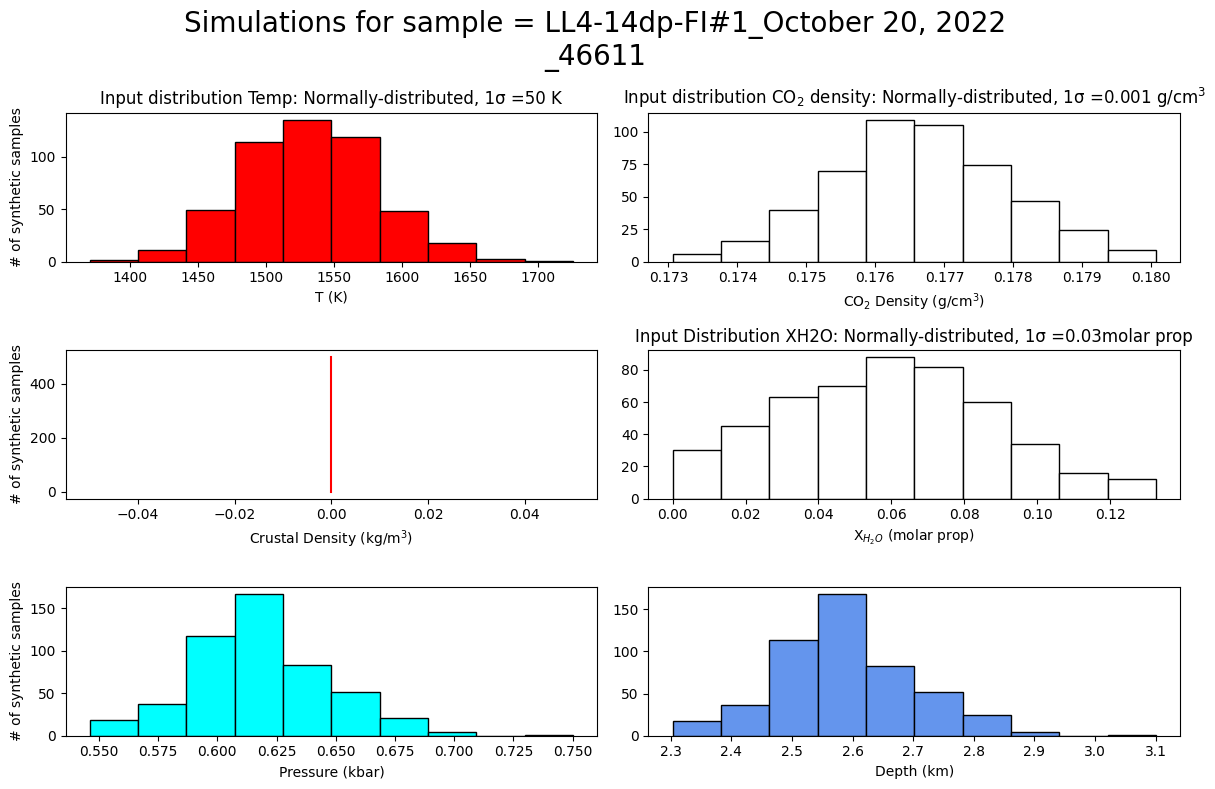

In [187]:
# ## Before doing this, to ensure proper merging we have to create a new column in LERZ2018
LERZ2018['MCSim_filename(_date_secsincemidnight)']=LERZ2018['Fluid inclusion ID']+"_"+LERZ2018['date'].astype('str')+"_"+LERZ2018['sec since midnight'].astype('str').str.split('.').str[0]

# ## We also create a new column with the CO2 density error, 
# ## if the measurement was averaged, the error is the standard deviation ('Density g/cm3_Raman_STD') 
# ## if it's a single measurement, it's the sigma from DiadFit ('CO2 density 1σ (g/cm3)')

LERZ2018['error_CO2_dens_STDifmean_σifnot'] = LERZ2018.apply(
    lambda row: row[ 'CO2 density standard deviation of repeats (g/cm3)'] if row['Mean of repeated Analyses (Yes/No)'] == 'Yes' else row['CO2 density 1σ (g/cm3)'],
    axis=1
)

## Now run the simulations
LERZ2018_MC_Av_rho_T_df_B, LERZ2018_MC_All_rho_T_df_B, LERZ2018_fig=pf.propagate_FI_uncertainty(
T_K=LERZ2018['Temp_from_Fo_all']+273.15,
error_T_K=LERZ2018['Temp_error'], error_type_T_K='Abs', error_dist_T_K='normal',
CO2_dens_gcm3=LERZ2018['CO2 density (g/cm3)'],error_CO2_dens=LERZ2018['error_CO2_dens_STDifmean_σifnot'], 
error_type_CO2_dens='Abs', error_dist_CO2_dens='normal',
XH2O=LERZ2018['XH2O_av_iteration3_final'], error_XH2O=pd.Series(0.5*np.abs(LERZ2018['XH2O_max_iteration3_final']-LERZ2018['XH2O_min_iteration3_final'])), error_type_XH2O='Abs', error_dist_XH2O='normal',
sample_ID=LERZ2018['MCSim_filename(_date_secsincemidnight)'],
model='denlinger_lerner',
N_dup=500, fig_i=0, plot_figure=True)


LERZ2018_fig.savefig(figpath+slash+'MCsimulation_LERZ2018.pdf')
LERZ2018_MC_Av_rho_T_df_B

### B. Merge results back into the main dataframe

### First, Lerner's data

In [188]:
# First, we rename the Filename column from the simulations, to merge 
AL25_MC_Av_rho_T_df_B=AL25_MC_Av_rho_T_df_B.rename(columns={'Filename':'MCSim_filename(_date_secsincemidnight)'})

# Then we merge back in using the special filename column
AL25_wcalcs = pd.merge(AL25,AL25_MC_Av_rho_T_df_B, how='outer', on='MCSim_filename(_date_secsincemidnight)', suffixes=['_RR', None])
AL25_wcalcs_final = pd.merge(Original_AL25,AL25_wcalcs, how='outer', on='Final_merge_column', suffixes=['_RRR', None]) ## Merges back in with the original df

AL25_wcalcs_final.head()

,Sample Name\n(melt inclusions and fluid inclusions)_RRR,Keanakākoʻi Tephra unit name\n(Swanson & Houghton 2018 nomenclature)_RRR,Sample_RRR,Keanakākoʻi Tephra unit description_RRR,Eruption Date (CE)_RRR,Sample Site: Latitude (WGS84)_RRR,Sample Site: Longitude (WGS84)_RRR,Inclusion type_RRR,Inclusion notes_RRR,Sulfide diameter (um)\nif present in melt inclusion_RRR,...,T_K_input,error_T_K,CO2_dens_gcm3_input,error_CO2_dens_gcm3,crust_dens_kgm3_input,error_crust_dens_kgm3,model,EOS,XH2O_input,error_XH2O
0,K97_22_1_1,J1,L25_Keana_J1,vitric ash associated with 1790 surge,1790,19.40562,-155.292818,melt inclusion,-,unknown if sulfide was present,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,K97_22_2_1,J1,L25_Keana_J1,vitric ash associated with 1790 surge,1790,19.40562,-155.292818,melt inclusion,-,unknown if sulfide was present,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,K97_22_5_1,J1,L25_Keana_J1,vitric ash associated with 1790 surge,1790,19.40562,-155.292818,melt inclusion,-,unknown if sulfide was present,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,K97_22m_2_1,J1,L25_Keana_J1,vitric ash associated with 1790 surge,1790,19.40562,-155.292818,melt inclusion,-,unknown if sulfide was present,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,K97_22m_2_1_matrix,J1,L25_Keana_J1,vitric ash associated with 1790 surge,1790,19.40562,-155.292818,matrix glass,-,-,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


#### First K23, also merge EBSD

In [189]:
EBSD_data1=pd.read_excel(MasterFolder +slash+"Data_processing_notebooks"+slash+'Data_reprocessing_Literature'+slash+'Data_Lit'+slash+'K23_EBSDmap'+slash+'K23_wholemount_052225 (montaged map)_grain_results.xlsx')
EBSD_data2=pd.read_excel(MasterFolder +slash+"Data_processing_notebooks"+slash+'Data_reprocessing_Literature'+slash+'Data_Lit'+slash+'K23_EBSDmap'+slash+"K23_manual_map_day"+slash+'K23_1_grain_results.xlsx')

EBSD_data=pd.concat([EBSD_data1,EBSD_data2])
EBSD_data=EBSD_data.rename(columns={'EBSD_name':'EBSD_simple_name','grainID':'EBSD_grainID','Filename':'EBSD_filename'})
EBSD_data['EBSD_simple_name']=EBSD_data['EBSD_filename']

K23_w_EBSD=pd.merge(left=K23,on=['EBSD_simple_name','EBSD_grainID'],right=EBSD_data,suffixes=('', '_EBSDdata'),how='left')

# First, we rename the Filename column from the simulations, to merge 
K23_MC_Av_rho_T_df_B=K23_MC_Av_rho_T_df_B.rename(columns={'Filename':'MCSim_filename(_date_secsincemidnight)'})

# Then we merge back in using the special filename column
K23_wcalcs = pd.merge(K23_w_EBSD,K23_MC_Av_rho_T_df_B, how='outer', on='MCSim_filename(_date_secsincemidnight)', suffixes=['_RR', None])
K23_wcalcs
# to make sure of duplicate columns can use this code: K23_wcalcs[K23_wcalcs.columns[K23_wcalcs.columns.str.contains('filename')]]


# K23_cut=K23.drop(columns=K23.columns[88:121])
# K23_cut.head()

,Column headers,py_index,Crystal Name,FI Name,Reported density mean of reps?,Density g/cm3,"σ Density g/cm3 (as plotted, from DiadFit for individual, Std dev for averaged FI)",STDofreps_Density g/cm3,σ Density g/cm3 (DiadFit),σ Density g/cm3 (from Ne+peakfit),...,T_K_input,error_T_K,CO2_dens_gcm3_input,error_CO2_dens_gcm3,crust_dens_kgm3_input,error_crust_dens_kgm3,model,EOS,XH2O_input,error_XH2O
0,NaN,0,K23_101,K23_101_FIC,No,0.085665,0.007736,NaN,0.007736,0.006738,...,1565.805593,50.0,0.085665,0.007736,None,0.0,denlinger_lerner,DZ06,0.108233,0.053578
1,NaN,1,K23_101,K23_101_FID,No,0.100137,0.005037,NaN,0.005037,0.003301,...,1565.805593,50.0,0.100137,0.005037,None,0.0,denlinger_lerner,DZ06,0.093852,0.046643
2,NaN,2,K23_102,K23_102_FIA,No,0.112454,0.004482,NaN,0.004482,0.002350,...,1564.096549,50.0,0.112454,0.004482,None,0.0,denlinger_lerner,DZ06,0.083756,0.041885
3,NaN,15,KS23_103,K23_103_FIC,No,0.114374,0.004013,NaN,0.004013,0.001231,...,1511.482018,50.0,0.114374,0.004013,None,0.0,denlinger_lerner,DZ06,0.085135,0.042535
4,NaN,16,KS23_103,K23_103_FID,Yes,0.126346,0.001619,0.001619,0.004087,0.001400,...,1511.482018,50.0,0.126346,0.001619,None,0.0,denlinger_lerner,DZ06,0.076872,0.038712
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
57,NaN,11,K23_7,K23_7_FIA,No,0.118112,0.003895,NaN,0.003895,0.000734,...,1457.137953,50.0,0.118112,0.003895,None,0.0,denlinger_lerner,DZ06,0.085425,0.042681
58,NaN,12,K23_7,K23_7_FIB,No,0.115662,0.004004,NaN,0.004004,0.001198,...,1457.137953,50.0,0.115662,0.004004,None,0.0,denlinger_lerner,DZ06,0.087248,0.043536
59,NaN,13,K23_7,K23_7_FIC,No,0.112891,0.004063,NaN,0.004063,0.001390,...,1457.137953,50.0,0.112891,0.004063,None,0.0,denlinger_lerner,DZ06,0.089382,0.044542
60,NaN,14,K23_9,K23_9_FIA,No,0.083276,0.004746,NaN,0.004746,0.002841,...,1504.386368,50.0,0.083276,0.004746,None,0.0,denlinger_lerner,DZ06,0.114549,0.056688


#### Next, LERZ2018

In [190]:
# First, we rename the Filename column from the simulations, to merge 
LERZ2018_MC_Av_rho_T_df_B=LERZ2018_MC_Av_rho_T_df_B.rename(columns={'Filename':'MCSim_filename(_date_secsincemidnight)'})

# Then we merge back in using the special filename column
LERZ2018_wcalcs = pd.merge(LERZ2018,LERZ2018_MC_Av_rho_T_df_B, how='outer', on='MCSim_filename(_date_secsincemidnight)', suffixes=['_RR', None])
LERZ2018_wcalcs
# to make sure of duplicate columns can use this code: LERZ2018_wcalcs[LERZ2018_wcalcs.columns[LERZ2018_wcalcs.columns.str.contains('filename')]]

,Py_index,Event Description,"Event ID (LL8 - July, LL7-Aug, LL4-May)",Host crystal ID,Fluid inclusion ID,Raman Data >,Fermi Diad separation ΔCO2 (cm-1),Corrected ΔCO2 (cm-1),Corrected ΔCO2 1σ (cm-1),CO2 density (g/cm3),...,T_K_input,error_T_K,CO2_dens_gcm3_input,error_CO2_dens_gcm3,crust_dens_kgm3_input,error_crust_dens_kgm3,model,EOS,XH2O_input,error_XH2O
0,0,"LERZ, Fissure 8, May 30th 2018",LL4,LL4-14dp,LL4-14dp-FI#1,ν1 refers to the low wavenumber band of the fe...,103.416763,103.186144,0.006461,0.176605,...,1532.873187,50.0,0.176605,0.001314,None,0.0,denlinger_lerner,DZ06,0.055466,0.029614
1,1,"LERZ, Fissure 8, May 30th 2018",LL4,LL4-14dp,LL4-14dp-FI#2,NaN,103.431244,103.195894,0.007137,0.180578,...,1531.215163,50.0,0.180578,0.002910,None,0.0,denlinger_lerner,DZ06,0.054643,0.029323
2,2,"LERZ, Fissure 8, May 30th 2018",LL4,LL4-14dp,LL4-14dp-MI#1,NaN,103.429713,103.196578,0.010404,0.180858,...,1534.365617,50.0,0.180858,0.004029,None,0.0,denlinger_lerner,DZ06,0.054514,0.029278
3,3,"LERZ, Fissure 8, May 30th 2018",LL4,LL4-21,LL4-21-#2,NaN,103.379425,103.122405,0.001766,0.147317,...,1486.618027,50.0,0.147317,0.001696,None,0.0,denlinger_lerner,DZ06,0.066753,0.034190
4,7,"LERZ, Fissure 8, May 30th 2018",LL4,LL4-21,LL4-21-MI#5,NaN,103.170121,102.953345,0.007431,0.080378,...,1534.208075,50.0,0.080378,0.002942,None,0.0,denlinger_lerner,DZ06,0.116065,0.057431
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
97,139,"LERZ, Fissure 8, Mid July 2018",LL8,LL8_406,LL8_406-FI#4,NaN,103.299352,103.047874,0.045655,0.117806,...,1531.924023,50.0,0.117806,0.018077,None,0.0,denlinger_lerner,DZ06,0.081526,0.040852
98,140,"LERZ, Fissure 8, Mid July 2018",LL8,LL8_406,LL8_406_FI#1,NaN,103.269854,103.026754,0.006926,0.109444,...,1531.924023,50.0,0.109444,0.005739,None,0.0,denlinger_lerner,DZ06,0.087831,0.043797
99,141,"LERZ, Fissure 8, Mid July 2018",LL8,LL8_406,LL8_406_FI#2,NaN,103.332884,103.089512,0.003002,0.134293,...,1531.924023,50.0,0.134293,0.001189,None,0.0,denlinger_lerner,DZ06,0.071222,0.036156
100,142,"LERZ, Fissure 8, Mid July 2018",LL8,LL8_406,LL8_406_FI#3,NaN,103.300169,103.057215,0.005555,0.121505,...,1531.924023,50.0,0.121505,0.002200,None,0.0,denlinger_lerner,DZ06,0.078976,0.039674


## 7. Merge matrix glass data in 
- First create a function to extract average glass data and std, then apply to each set 
- Note that K23 does not have glass data

In [191]:
### Create reusable function to average glass data and calculate std 
# def combine_strings_with_counts(series):
#     """
#     Combine string values into 'value(count)' joined by underscores.
#     NaNs are represented as ' ' unless all values are NaN.
#     """
#     if series.isna().all():
#         return np.nan

#     filled = series.fillna(" ").astype(str)
#     counts = filled.value_counts()

#     return "_".join(f"{val}({cnt})" for val, cnt in counts.items())



def average_by_col(
    Data,
    group_col="Sample",
    suffix="_Gl",
    averaged_col_name="averaged?",
    non_numeric_behavior="first"  # NEW
):
    """
    Group a DataFrame by `group_col`, average numeric columns,
    handle non-numeric columns according to `non_numeric_behavior`,
    append STD columns, flag whether rows were averaged,
    and rename columns with a suffix.

    non_numeric_behavior:
        - "first" : keep first value per group (default)
        - "last"  : keep last value per group
        - "skip"  : drop non-numeric columns entirely
    """

    grouped = Data.groupby(group_col)

    # Separate numeric and non-numeric columns
    numeric_cols = Data.select_dtypes(include='number')
    non_numeric_cols = Data.select_dtypes(exclude='number')

    # Aggregate numeric columns
    numeric_Data_averaged_mean = grouped[numeric_cols.columns].mean()
    numeric_Data_averaged_std = grouped[numeric_cols.columns].std()

    if non_numeric_behavior == "first":
        non_numeric_Data_averaged = grouped[non_numeric_cols.columns].first()

    elif non_numeric_behavior == "last":
        non_numeric_Data_averaged = grouped[non_numeric_cols.columns].last()

    elif non_numeric_behavior == "skip":
        non_numeric_Data_averaged = (
            grouped[[group_col]].first()
            if group_col in non_numeric_cols.columns
            else None
        )
    else:
        raise ValueError(
            "non_numeric_behavior must be one of: 'first', 'last', 'skip'"
        )

    # Concatenate aggregated data
    Data_averaged = pd.concat(
        [numeric_Data_averaged_mean, non_numeric_Data_averaged]
        if non_numeric_Data_averaged is not None
        else [numeric_Data_averaged_mean],
        axis=1
    )

    if non_numeric_behavior != "skip":
        Data_averaged = Data_averaged.reindex(columns=Data.columns)

    # Add standard deviation columns
    Data_averaged = pd.concat(
        [Data_averaged, numeric_Data_averaged_std.add_suffix('_STD')],
        axis=1
    )

    # Reset index
    Data_averaged = Data_averaged.reset_index(drop=True)

    # Row counts
    row_counts = grouped.size().reset_index(name='row_count')
    row_counts[averaged_col_name] = 'No'
    row_counts['#of analyses (when averaged)'] = pd.NA
    row_counts.loc[row_counts['row_count'] > 1, '#of analyses (when averaged)'] = row_counts['row_count']
    row_counts.loc[row_counts['row_count'] > 1, averaged_col_name] = 'Yes'

    # Merge averaged flag
    Data_averaged = pd.merge(
        Data_averaged,
        row_counts[[group_col, averaged_col_name,'#of analyses (when averaged)']],
        on=group_col,
        how='left'
    )

    Data_averaged[averaged_col_name] = Data_averaged[averaged_col_name].fillna('No')
    Data_averaged['non_numeric_column_behavior_used (First/Last instance kept or skipped)'] = non_numeric_behavior
    # Rename columns
    Data_averaged_renamed = Data_averaged.rename(
        columns=lambda x: x + suffix if x != group_col else group_col
    )

    return Data_averaged_renamed


### First, LERZ 2018

In [196]:
LERZ2018_glass=pd.read_excel(MasterFolder +slash+"Data_processing_notebooks"+slash+
                             'Data_reprocessing_Literature'+slash+'Data_Lit'+slash+'Supplement_Wieser_et_al_G3.xlsx',sheet_name="Matrix_Glasses",skiprows=[1,2])
LERZ2018_glass =LERZ2018_glass.loc[:, ~LERZ2018_glass.columns.str.contains('Unnamed')]
LERZ2018_glass.columns = LERZ2018_glass.columns.str.strip()

LERZ2018_glass =LERZ2018_glass[LERZ2018_glass['Specific ID (LL8 - lab code for F8 Mid July, LL7- lab code for Aug 1st, LL4- lab code for May 30th)'].str.contains("LL8|LL4|LL7")]
LERZ2018_glass.rename(columns={'Specific ID (LL8 - lab code for F8 Mid July, LL7- lab code for Aug 1st, LL4- lab code for May 30th)': 
                               'Event ID (LL8 - July, LL7-Aug, LL4-May)'}, inplace=True)

LERZ2018_glass_averaged = average_by_col(LERZ2018_glass.copy(),group_col='Event ID (LL8 - July, LL7-Aug, LL4-May)',non_numeric_behavior='skip').dropna(axis=1)
LERZ2018_glass_averaged.insert(0, "Event ID (LL8 - July, LL7-Aug, LL4-May)", LERZ2018_glass_averaged.pop("Event ID (LL8 - July, LL7-Aug, LL4-May)"))

LERZ2018_finalmerge=pd.merge(left=LERZ2018_wcalcs,right=LERZ2018_glass_averaged,on='Event ID (LL8 - July, LL7-Aug, LL4-May)',how="left")

display(LERZ2018_glass_averaged)
display(LERZ2018_finalmerge)
LERZ2018_glass_averaged


,"Event ID (LL8 - July, LL7-Aug, LL4-May)",Na2O_Gl,Al2O3_Gl,P2O5_Gl,CaO_Gl,K2O_Gl,TiO2_Gl,SiO2_Gl,MgO_Gl,FeO_Gl,...,K2O_STD_Gl,TiO2_STD_Gl,SiO2_STD_Gl,MgO_STD_Gl,FeO_STD_Gl,MnO_STD_Gl,H2O (wt%)_STD_Gl,averaged?_Gl,#of analyses (when averaged)_Gl,non_numeric_column_behavior_used (First/Last instance kept or skipped)_Gl
0,LL4,2.512192,13.074163,0.293895,10.208868,0.545984,2.867900,50.490679,5.942205,11.555929,...,0.023881,0.031785,0.607669,0.074291,0.175527,0.039833,0.011157,Yes,19,skip
1,LL7,2.412159,13.315968,0.263844,10.713206,0.480526,2.598768,50.359618,6.432894,11.028091,...,0.032037,0.017701,0.560223,0.140388,0.215600,0.036929,0.000707,Yes,17,skip
2,LL8,2.367730,13.308756,0.244488,10.795890,0.475922,2.559322,50.618228,6.589394,10.933992,...,0.022529,0.020094,0.251381,0.087161,0.208341,0.040416,0.002659,Yes,25,skip


,Py_index,Event Description,"Event ID (LL8 - July, LL7-Aug, LL4-May)",Host crystal ID,Fluid inclusion ID,Raman Data >,Fermi Diad separation ΔCO2 (cm-1),Corrected ΔCO2 (cm-1),Corrected ΔCO2 1σ (cm-1),CO2 density (g/cm3),...,K2O_STD_Gl,TiO2_STD_Gl,SiO2_STD_Gl,MgO_STD_Gl,FeO_STD_Gl,MnO_STD_Gl,H2O (wt%)_STD_Gl,averaged?_Gl,#of analyses (when averaged)_Gl,non_numeric_column_behavior_used (First/Last instance kept or skipped)_Gl
0,0,"LERZ, Fissure 8, May 30th 2018",LL4,LL4-14dp,LL4-14dp-FI#1,ν1 refers to the low wavenumber band of the fe...,103.416763,103.186144,0.006461,0.176605,...,0.023881,0.031785,0.607669,0.074291,0.175527,0.039833,0.011157,Yes,19,skip
1,1,"LERZ, Fissure 8, May 30th 2018",LL4,LL4-14dp,LL4-14dp-FI#2,NaN,103.431244,103.195894,0.007137,0.180578,...,0.023881,0.031785,0.607669,0.074291,0.175527,0.039833,0.011157,Yes,19,skip
2,2,"LERZ, Fissure 8, May 30th 2018",LL4,LL4-14dp,LL4-14dp-MI#1,NaN,103.429713,103.196578,0.010404,0.180858,...,0.023881,0.031785,0.607669,0.074291,0.175527,0.039833,0.011157,Yes,19,skip
3,3,"LERZ, Fissure 8, May 30th 2018",LL4,LL4-21,LL4-21-#2,NaN,103.379425,103.122405,0.001766,0.147317,...,0.023881,0.031785,0.607669,0.074291,0.175527,0.039833,0.011157,Yes,19,skip
4,7,"LERZ, Fissure 8, May 30th 2018",LL4,LL4-21,LL4-21-MI#5,NaN,103.170121,102.953345,0.007431,0.080378,...,0.023881,0.031785,0.607669,0.074291,0.175527,0.039833,0.011157,Yes,19,skip
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
97,139,"LERZ, Fissure 8, Mid July 2018",LL8,LL8_406,LL8_406-FI#4,NaN,103.299352,103.047874,0.045655,0.117806,...,0.022529,0.020094,0.251381,0.087161,0.208341,0.040416,0.002659,Yes,25,skip
98,140,"LERZ, Fissure 8, Mid July 2018",LL8,LL8_406,LL8_406_FI#1,NaN,103.269854,103.026754,0.006926,0.109444,...,0.022529,0.020094,0.251381,0.087161,0.208341,0.040416,0.002659,Yes,25,skip
99,141,"LERZ, Fissure 8, Mid July 2018",LL8,LL8_406,LL8_406_FI#2,NaN,103.332884,103.089512,0.003002,0.134293,...,0.022529,0.020094,0.251381,0.087161,0.208341,0.040416,0.002659,Yes,25,skip
100,142,"LERZ, Fissure 8, Mid July 2018",LL8,LL8_406,LL8_406_FI#3,NaN,103.300169,103.057215,0.005555,0.121505,...,0.022529,0.020094,0.251381,0.087161,0.208341,0.040416,0.002659,Yes,25,skip


,"Event ID (LL8 - July, LL7-Aug, LL4-May)",Na2O_Gl,Al2O3_Gl,P2O5_Gl,CaO_Gl,K2O_Gl,TiO2_Gl,SiO2_Gl,MgO_Gl,FeO_Gl,...,K2O_STD_Gl,TiO2_STD_Gl,SiO2_STD_Gl,MgO_STD_Gl,FeO_STD_Gl,MnO_STD_Gl,H2O (wt%)_STD_Gl,averaged?_Gl,#of analyses (when averaged)_Gl,non_numeric_column_behavior_used (First/Last instance kept or skipped)_Gl
0,LL4,2.512192,13.074163,0.293895,10.208868,0.545984,2.867900,50.490679,5.942205,11.555929,...,0.023881,0.031785,0.607669,0.074291,0.175527,0.039833,0.011157,Yes,19,skip
1,LL7,2.412159,13.315968,0.263844,10.713206,0.480526,2.598768,50.359618,6.432894,11.028091,...,0.032037,0.017701,0.560223,0.140388,0.215600,0.036929,0.000707,Yes,17,skip
2,LL8,2.367730,13.308756,0.244488,10.795890,0.475922,2.559322,50.618228,6.589394,10.933992,...,0.022529,0.020094,0.251381,0.087161,0.208341,0.040416,0.002659,Yes,25,skip


### Next, let's do Lerner

In [193]:
### First let's make sure our recalculated samples have a sample ID to merge glasses on
AL25_wcalcs["Sample_ID"] = AL25_wcalcs["Sample Name\n(melt inclusions and fluid inclusions)"].str.split("_").str[0]
AL25_wcalcs.insert(0, "Sample_ID", AL25_wcalcs.pop("Sample_ID"))
AL25_wcalcs.head()

,Sample_ID,Sample Name\n(melt inclusions and fluid inclusions),Keanakākoʻi Tephra unit name\n(Swanson & Houghton 2018 nomenclature),Sample,Keanakākoʻi Tephra unit description,Eruption Date (CE),Sample Site: Latitude (WGS84),Sample Site: Longitude (WGS84),Inclusion type,Inclusion notes,...,T_K_input,error_T_K,CO2_dens_gcm3_input,error_CO2_dens_gcm3,crust_dens_kgm3_input,error_crust_dens_kgm3,model,EOS,XH2O_input,error_XH2O
0,K99-6,K99-6_1c,B,L25_Keana_B,lower reticulite,1500,19.42567,-155.25163,fluid inclusion,Isolated fluid inclusion,...,1471.001616,50.0,0.120007,3.129780e-03,None,0.0,denlinger_lerner,DZ06,0.083273,0.041673
1,K99-6,K99-6_2d,B,L25_Keana_B,lower reticulite,1500,19.42567,-155.25163,fluid inclusion,Isolated fluid inclusion,...,1485.020696,50.0,0.137424,2.605323e-14,None,0.0,denlinger_lerner,DZ06,0.071719,0.036383
2,K99-6,K99-6_5b,B,L25_Keana_B,lower reticulite,1500,19.42567,-155.25163,fluid inclusion,Isolated fluid inclusion,...,1477.188878,50.0,0.126863,8.978184e-04,None,0.0,denlinger_lerner,DZ06,0.078322,0.039382
3,K99-6,K99-6_5d,B,L25_Keana_B,lower reticulite,1500,19.42567,-155.25163,fluid inclusion,Isolated fluid inclusion,...,1477.188878,50.0,0.114421,2.335182e-03,None,0.0,denlinger_lerner,DZ06,0.087029,0.043429
4,K99-6,K99-6_5e,B,L25_Keana_B,lower reticulite,1500,19.42567,-155.25163,fluid inclusion,Isolated fluid inclusion,...,1477.188878,50.0,0.118254,2.850298e-04,None,0.0,denlinger_lerner,DZ06,0.084181,0.042095


In [208]:
### Now let's get the glass data and average it
AL25_glass=pd.read_excel(MasterFolder +slash+"Data_processing_notebooks"+slash+'Data_reprocessing_Literature'+slash+'Data_Lit'+slash+'Lerneretal25_supplement.xlsx',
                   sheet_name="1_Keanakakoi inclusion data",skiprows=[0] + list(range(2, 232)))
## clean up the dataframe first
AL25_glass.columns = AL25_glass.columns.str.replace(' wt% (raw)', '%sub%', regex=False)
AL25_glass.columns = AL25_glass.columns.str.replace(' wt%', '_norm', regex=False)
AL25_glass.columns = AL25_glass.columns.str.replace('%sub%', '', regex=False)
AL25_glass.columns = AL25_glass.columns.str.strip()
AL25_glass.columns = AL25_glass.columns.str.replace('liq ', '', regex=False)

AL25_glass=AL25_glass.dropna(subset="Keanakākoʻi Tephra unit name\n(Swanson & Houghton 2018 nomenclature)")
AL25_glass =AL25_glass.loc[:, ~AL25_glass.columns.str.contains('Unnamed')].copy()
AL25_glass.insert(loc=2,column='Sample',value="L25_Keana_"+AL25['Keanakākoʻi Tephra unit name\n(Swanson & Houghton 2018 nomenclature)'])
AL25_glass=AL25_glass.replace("-", np.nan).dropna(axis=1)

AL25_glass["Sample_ID"] = AL25_glass["Sample Name\n(melt inclusions and fluid inclusions)"].str.split("_").str[0]
AL25_glass.insert(0, "Sample_ID", AL25_glass.pop("Sample_ID"))

## now average
AL25_glass_averaged = average_by_col(AL25_glass.copy(),group_col='Sample_ID',non_numeric_behavior='skip').dropna(axis=1)
AL25_glass_averaged.insert(0, "Sample_ID", AL25_glass_averaged.pop("Sample_ID"))

AL25_finalmerge=pd.merge(left=AL25_wcalcs,right=AL25_glass_averaged,on='Sample_ID',how="left")

display(AL25_glass_averaged)
display(AL25_finalmerge.head())

/opt/anaconda3/envs/py313/lib/python3.13/site-packages/openpyxl/worksheet/_reader.py:329: UserWarning: Conditional Formatting extension is not supported and will be removed
  warn(msg)


,Sample_ID,Sample Site: Latitude (WGS84)_Gl,Sample Site: Longitude (WGS84)_Gl,Quench Temperature (°C) (Helz and Thornber 1987)_Gl,Mg#_Gl,SiO2_norm_Gl,TiO2_norm_Gl,Al2O3 _norm_Gl,FeOT_norm_Gl,MnO_norm_Gl,...,MgO_STD_Gl,CaO_STD_Gl,Na2O_STD_Gl,K2O_STD_Gl,P2O5_STD_Gl,S ppm (raw)_STD_Gl,un-normalized total_norm (anhydrous) (raw)_STD_Gl,averaged?_Gl,#of analyses (when averaged)_Gl,non_numeric_column_behavior_used (First/Last instance kept or skipped)_Gl
0,K97,19.405620,-155.292818,1186.695180,59.067071,50.928256,2.437015,13.231252,10.712170,0.160763,...,0.806828,0.205233,0.151226,0.028822,0.013809,292.950508,0.830282,Yes,5,skip
1,K99,19.425670,-155.251630,1154.639700,52.720559,50.411678,2.574607,13.948787,11.227338,0.175656,...,0.149907,0.068589,0.014142,0.006364,0.024042,70.710678,0.193040,Yes,2,skip
2,K99-5,19.389810,-155.292290,1161.879305,54.175174,51.397488,2.292485,14.081216,11.030709,0.166091,...,0.646945,0.360699,0.071659,0.020825,0.014972,429.126519,1.059733,Yes,15,skip
3,K99-6,19.425670,-155.251630,1166.536461,55.659940,51.327345,2.257198,13.966068,10.846868,0.165509,...,0.157612,0.092254,0.100807,0.025645,0.009856,562.899186,1.032633,Yes,15,skip
4,SW3,19.389810,-155.292290,1192.207017,58.568142,50.874436,2.317854,13.243946,11.102138,0.169446,...,1.309359,0.324203,0.074182,0.037143,0.010565,298.891625,0.920924,Yes,13,skip
5,SW7,19.390349,-155.293411,1197.090900,59.245389,50.601841,2.323180,12.977793,11.273914,0.190730,...,0.049497,0.015556,0.042426,0.004243,0.034648,14.142136,0.695086,Yes,2,skip


,Sample_ID,Sample Name\n(melt inclusions and fluid inclusions),Keanakākoʻi Tephra unit name\n(Swanson & Houghton 2018 nomenclature),Sample,Keanakākoʻi Tephra unit description,Eruption Date (CE),Sample Site: Latitude (WGS84),Sample Site: Longitude (WGS84),Inclusion type,Inclusion notes,...,MgO_STD_Gl,CaO_STD_Gl,Na2O_STD_Gl,K2O_STD_Gl,P2O5_STD_Gl,S ppm (raw)_STD_Gl,un-normalized total_norm (anhydrous) (raw)_STD_Gl,averaged?_Gl,#of analyses (when averaged)_Gl,non_numeric_column_behavior_used (First/Last instance kept or skipped)_Gl
0,K99-6,K99-6_1c,B,L25_Keana_B,lower reticulite,1500,19.42567,-155.25163,fluid inclusion,Isolated fluid inclusion,...,0.157612,0.092254,0.100807,0.025645,0.009856,562.899186,1.032633,Yes,15,skip
1,K99-6,K99-6_2d,B,L25_Keana_B,lower reticulite,1500,19.42567,-155.25163,fluid inclusion,Isolated fluid inclusion,...,0.157612,0.092254,0.100807,0.025645,0.009856,562.899186,1.032633,Yes,15,skip
2,K99-6,K99-6_5b,B,L25_Keana_B,lower reticulite,1500,19.42567,-155.25163,fluid inclusion,Isolated fluid inclusion,...,0.157612,0.092254,0.100807,0.025645,0.009856,562.899186,1.032633,Yes,15,skip
3,K99-6,K99-6_5d,B,L25_Keana_B,lower reticulite,1500,19.42567,-155.25163,fluid inclusion,Isolated fluid inclusion,...,0.157612,0.092254,0.100807,0.025645,0.009856,562.899186,1.032633,Yes,15,skip
4,K99-6,K99-6_5e,B,L25_Keana_B,lower reticulite,1500,19.42567,-155.25163,fluid inclusion,Isolated fluid inclusion,...,0.157612,0.092254,0.100807,0.025645,0.009856,562.899186,1.032633,Yes,15,skip


In [213]:
AL25_glass

,Sample_ID,Sample Name\n(melt inclusions and fluid inclusions),Keanakākoʻi Tephra unit name\n(Swanson & Houghton 2018 nomenclature),Keanakākoʻi Tephra unit description,Eruption Date (CE),Sample Site: Latitude (WGS84),Sample Site: Longitude (WGS84),Inclusion type,Inclusion analytical notes,Analysis date,...,Al2O3,FeOT,MnO,MgO,CaO,Na2O,K2O,P2O5,S ppm (raw),un-normalized total_norm (anhydrous) (raw)
1,K97,K97_23_4_1_MG,K1,golden pumice,1790-1820,19.405620,-155.292818,matrix glass,Unit V of Decker and Christiansen 1984. Sample...,2001,...,13.1640,9.42900,0.145000,9.23500,11.16400,2.14200,0.346000,0.211000,960.00,99.027000
2,K97,K97_23_4_1_MG_2,K1,golden pumice,1790-1820,19.405620,-155.292818,matrix glass,Unit V of Decker and Christiansen 1984. Sample...,2001,...,13.3390,9.71400,0.112000,9.18400,11.03800,2.17600,0.383000,0.239000,960.00,99.708000
3,K97,K97_23_10_MG,K1,golden pumice,1790-1820,19.405620,-155.292818,matrix glass,Unit V of Decker and Christiansen 1984. Sample...,2001,...,12.9740,10.99500,0.168000,9.10900,10.61700,2.10100,0.419000,0.212000,880.00,99.625000
5,SW7,SW7_7_1_MG1,K1,golden pumice,1790-1820,19.390349,-155.293411,interstitial glass,Unit VI of Decker and Christiansen 1984.,2001,...,13.0440,11.13800,0.189000,9.14400,10.42400,2.05900,0.417000,0.299000,1290.00,99.587000
6,SW7,SW7_7_1_MG2,K1,golden pumice,1790-1820,19.390349,-155.293411,interstitial glass,Unit VI of Decker and Christiansen 1984,2001,...,12.6780,11.20500,0.189000,9.07400,10.40200,2.11900,0.411000,0.250000,1270.00,98.604000
9,K97,K97_22m_2_1_matrix,J1,vitric ash associated with 1790 surge,1790,19.405620,-155.292818,matrix glass,Unit V of Decker and Christiansen 1984. Sample...,2001,...,13.0640,11.30100,0.184000,7.85000,10.92600,2.04400,0.412000,0.239000,360.00,98.165000
10,K97,K97_22m_2_1_matrixb,J1,vitric ash associated with 1790 surge,1790,19.405620,-155.292818,matrix glass,Unit V of Decker and Christiansen 1984. Sample...,2001,...,12.8760,11.50000,0.185000,7.58100,11.00900,1.79600,0.394000,0.228000,450.00,97.888000
16,K99-5,K99-5_1_matrixG_1,"D, upper",vitric ash 2A2,1500-1650,19.389810,-155.292290,matrix glass,possibly slightly structured Fe-XANES analysis...,2021-11-15 00:00:00,...,14.2209,11.27320,0.183395,6.59071,11.11800,2.32324,0.446608,0.220274,703.14,100.887793
17,K99-5,K99-5_1_matrixG_2,"D, upper",vitric ash 2A2,1500-1650,19.389810,-155.292290,matrix glass,single EPMA analysis,2021-11-15 00:00:00,...,14.6068,10.93350,0.160919,7.43284,10.57330,2.32134,0.447815,0.217405,356.13,100.583778
18,K99-5,K99-5_11_matrixG,"D, upper",vitric ash 2A2,1500-1650,19.389810,-155.292290,matrix glass,single EPMA analysis,2021-11-15 00:00:00,...,13.2600,10.57150,0.156670,8.93823,9.83046,2.33460,0.461581,0.221719,327.43,99.873634


## 8. Final data export for plotting

In [209]:
AL25_finalmerge.to_excel(compilation_folder+slash+'Lerner2025_recalculated.xlsx')
LERZ2018_finalmerge.to_excel(compilation_folder+slash+'LERZ2018_recalculated.xlsx')
K23_wcalcs.to_excel(compilation_folder+slash+'K23_recalculated.xlsx')